# Algae Growth

The rewriting rules of the L-system are as follows:

axiom: A

rule 1: A →→ AB

rule 2: B →→ A

In VPL, this L-system would be implemented as a graph where the nodes can be of type A or B and inherit from the abstract type Node. It is advised to include type definitions in a module to avoid having to restart the Julia session whenever we want to redefine them. 

Explanation about L-system of algae growth: [algae growth](https://en.wikipedia.org/wiki/L-system#Example_1:_Algae)

In [1]:
using VirtualPlantLab
import CairoMakie

In [2]:
module algae
    import VirtualPlantLab: Node
    struct A <: Node end
    struct B <: Node end
end
import .algae

In [3]:
axiom = algae.A()

Main.algae.A()

In [4]:
rule1 = Rule(algae.A, rhs = x -> algae.A()+algae.B())
rule2 = Rule(algae.B, rhs = x -> algae.A())

Rule replacing nodes of type Main.algae.B without context capturing.


## Create graph

In [5]:
organism = Graph(axiom = axiom, rules = (rule1, rule2))

Dynamic graph with 1 nodes of types Main.algae.A and 2 rewriting rules.


In [6]:
draw(organism)

The graph only has one node, so no visualization was made


## Update graph with rewrite! rules

In [7]:
rewrite!(organism)
# apply multipe iterations of rewriting with simple loop
for i in 1:4
    rewrite!(organism)
end

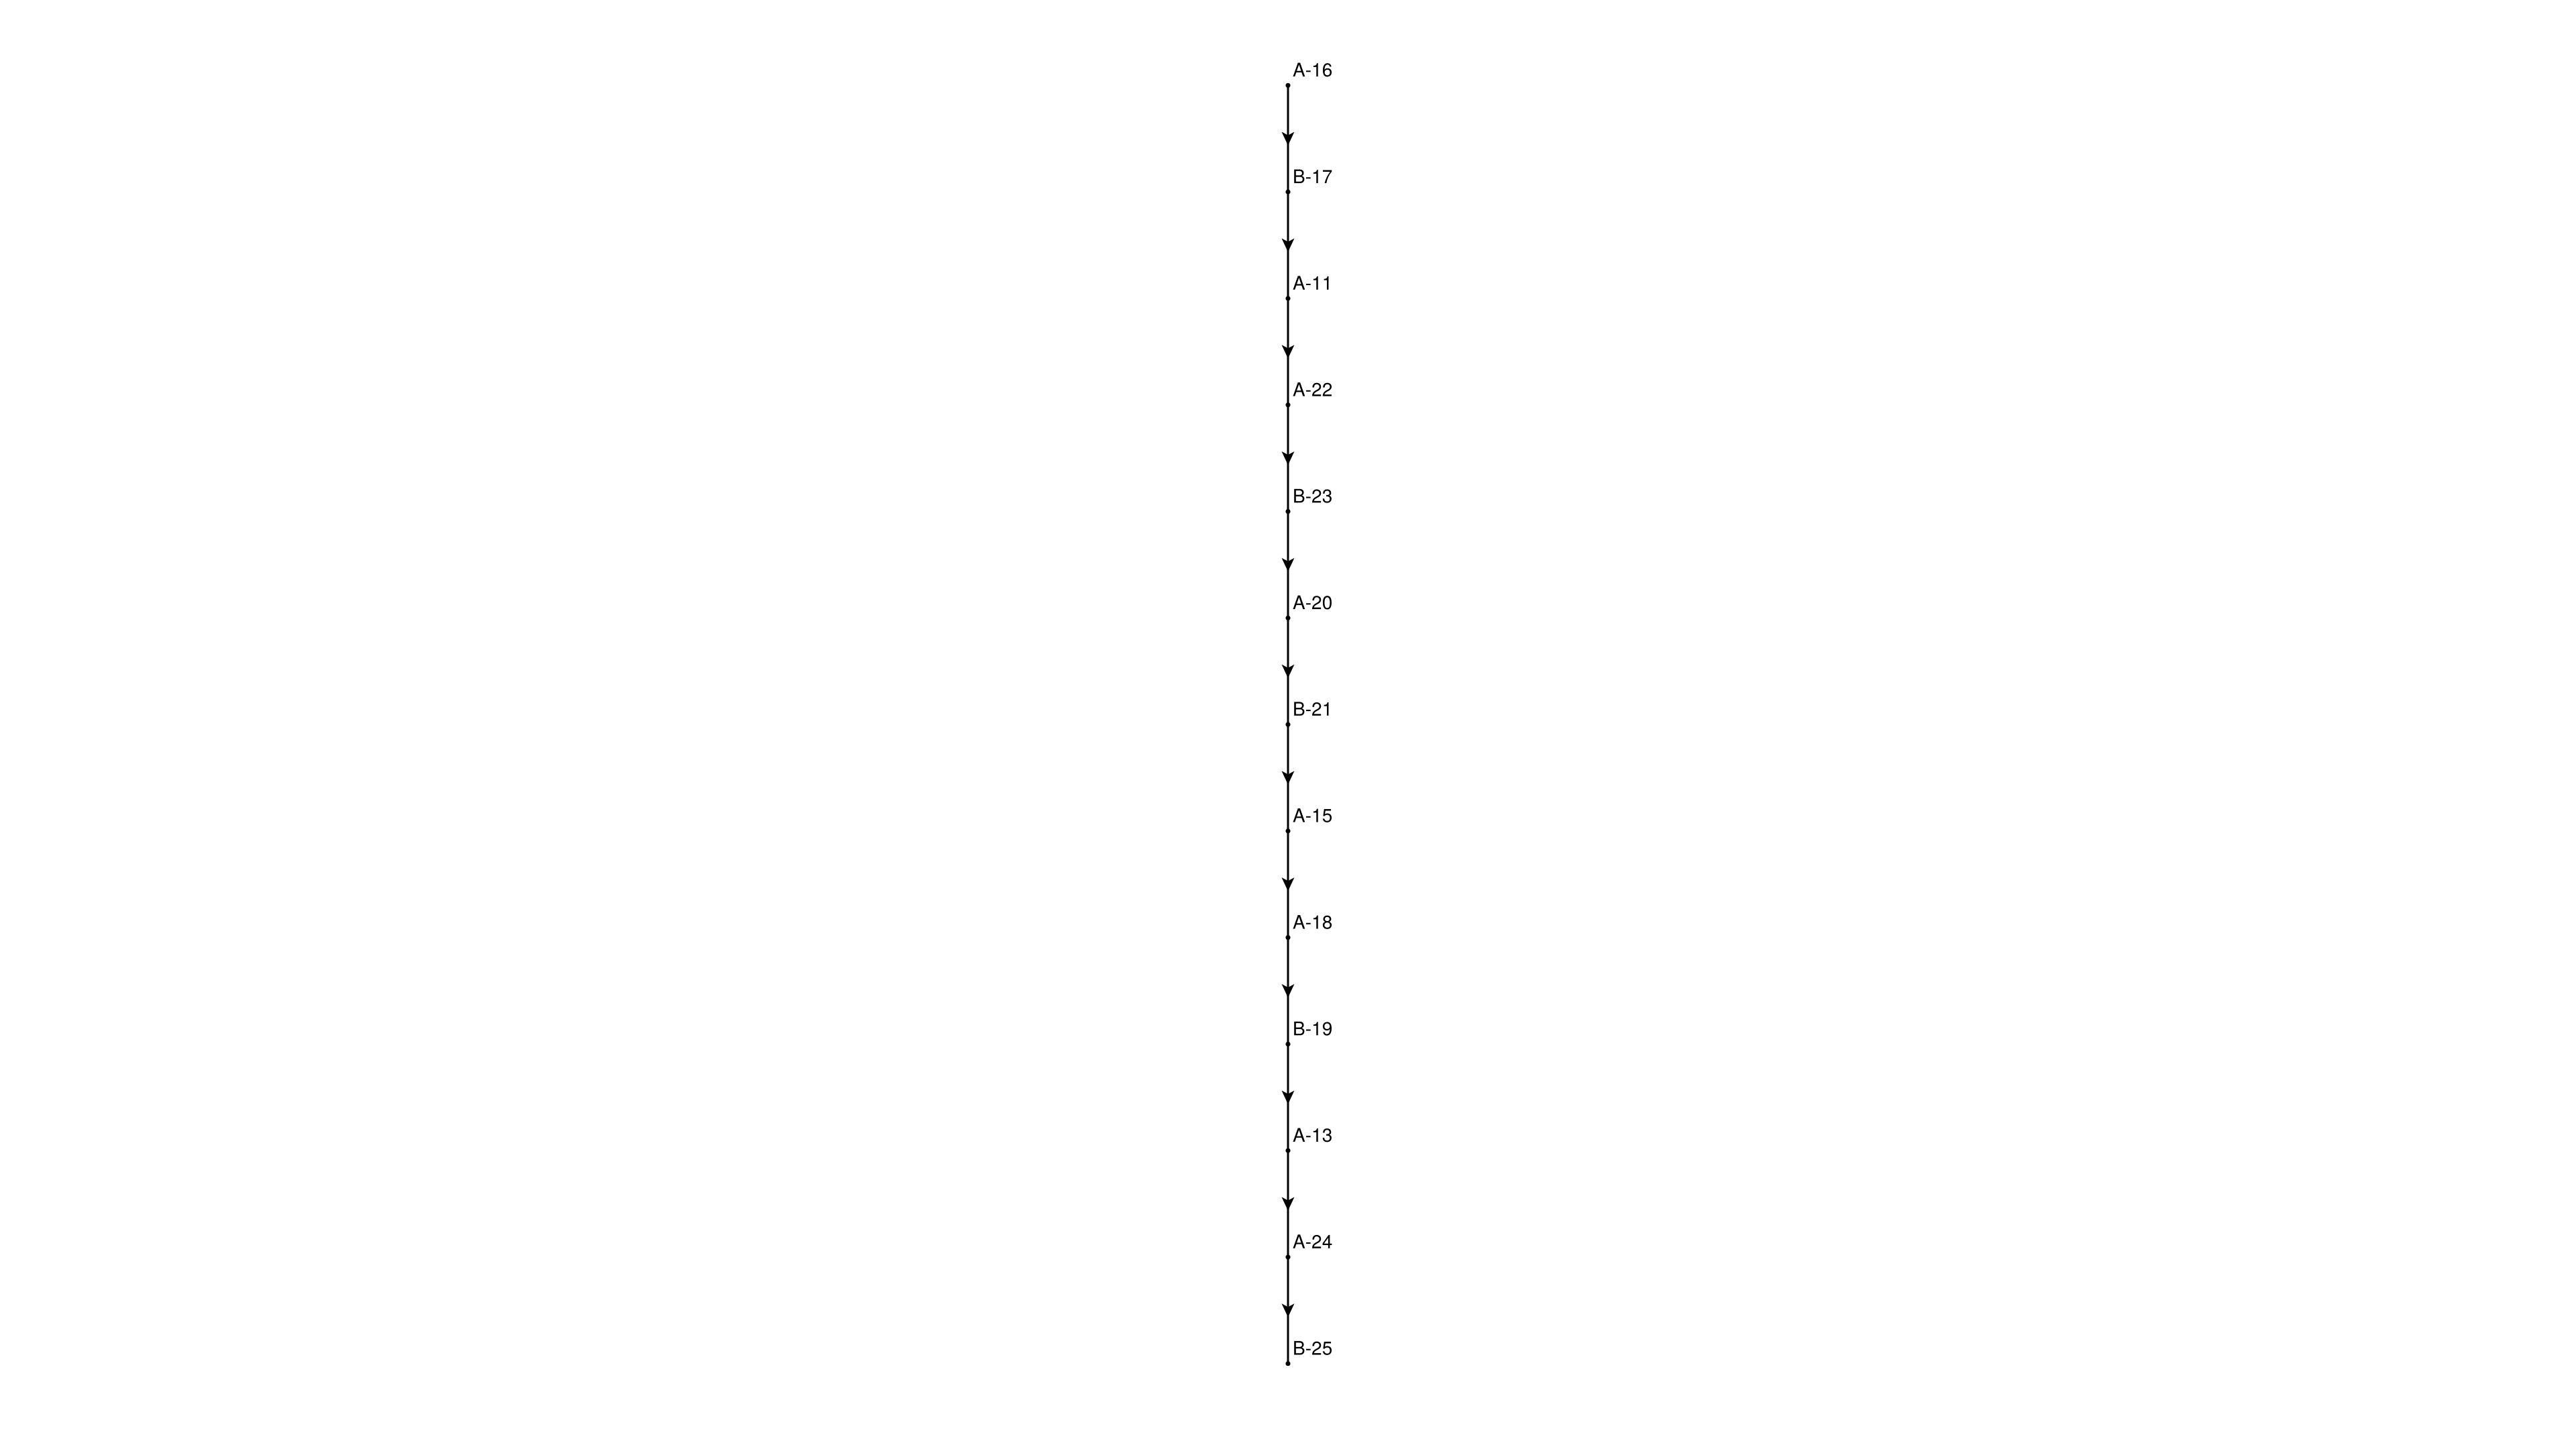

In [8]:
draw(organism)

# The Koch Snowflake

In order to implement the construction process of a Koch snowflake in VPL we need to understand how a 3D structure can be generated from a graph of nodes. VPL uses a procedural approach to generate of structure based on the concept of turtle graphics.

The idea behind this approach is to imagine a turtle located in space with a particular position and orientation. The turtle then starts consuming the different nodes in the graph (following its topological structure) and generates 3D structures as defined by the user for each type of node. The consumption of a node may also include instructions to move and/or rotate the turtle, which allows to alter the relative position of the different 3D structures described by a graph.

The construction process of the Koch snowflake in VPL could then be represented by the following axiom and rewriting rule:

axiom: E(L) + RU(120) + E(L) + RU(120) + E(L) rule: E(L) → E(L/3) + RU(-60) + E(L/3) + RU(120) + E(L/3) + RU(-60) + E(L/3)

Where E represent and edge of a given length (given in parenthesis) and RU represents a rotation of the turtle around the upward axis, with angle of rotation given in parenthesis in hexadecimal degrees. 

In [9]:
using ColorTypes # to define colors for the rendering

module sn
    import VirtualPlantLab
    struct E <: VirtualPlantLab.Node
        length::Float64
    end
end

import .sn

In [10]:
const L = 1.0
axiom = sn.E(L) + VirtualPlantLab.RU(120.0) + sn.E(L) + VirtualPlantLab.RU(120.0) + sn.E(L)

PlantGraphs.StaticGraph(OrderedCollections.OrderedDict{Int64, PlantGraphs.GraphNode}(26 => PlantGraphs.GraphNode{Main.sn.E}(Main.sn.E(1.0), OrderedCollections.OrderedSet{Int64}([27]), missing, 26), 27 => PlantGraphs.GraphNode{RU{Float64}}(RU{Float64}(120.0), OrderedCollections.OrderedSet{Int64}([28]), 26, 27), 28 => PlantGraphs.GraphNode{Main.sn.E}(Main.sn.E(1.0), OrderedCollections.OrderedSet{Int64}([29]), 27, 28), 29 => PlantGraphs.GraphNode{RU{Float64}}(RU{Float64}(120.0), OrderedCollections.OrderedSet{Int64}([30]), 28, 29), 30 => PlantGraphs.GraphNode{Main.sn.E}(Main.sn.E(1.0), OrderedCollections.OrderedSet{Int64}(), 29, 30)), OrderedCollections.OrderedDict{DataType, OrderedCollections.OrderedSet{Int64}}(Main.sn.E => OrderedCollections.OrderedSet{Int64}([26, 28, 30]), RU{Float64} => OrderedCollections.OrderedSet{Int64}([27, 29])), 26, 30)

RU: Rotate the turtle around the 'up' axis. 

In [11]:
function Kochsnowflake(x)
    L = data(x).length
    sn.E(L/3) + RU(-60.0) + sn.E(L/3) + RU(120.0) + sn.E(L/3) + RU(60.0) + sn.E(L/3)
end
rule = Rule(sn.E, rhs = Kochsnowflake)

Rule replacing nodes of type Main.sn.E without context capturing.


In [12]:
Koch = Graph(axiom = axiom, rules = Tuple(rule))

Dynamic graph with 5 nodes of types Main.sn.E,RU{Float64} and 1 rewriting rules.


In [13]:
function VirtualPlantLab.feed!(turtle::Turtle, e::sn.E, vars)
    HollowCylinder!(turtle, length=e.length, width= e.length/10,
                    height = e.length/10, move = true,
                    colors = rand(RGB))
                    return nothing
end

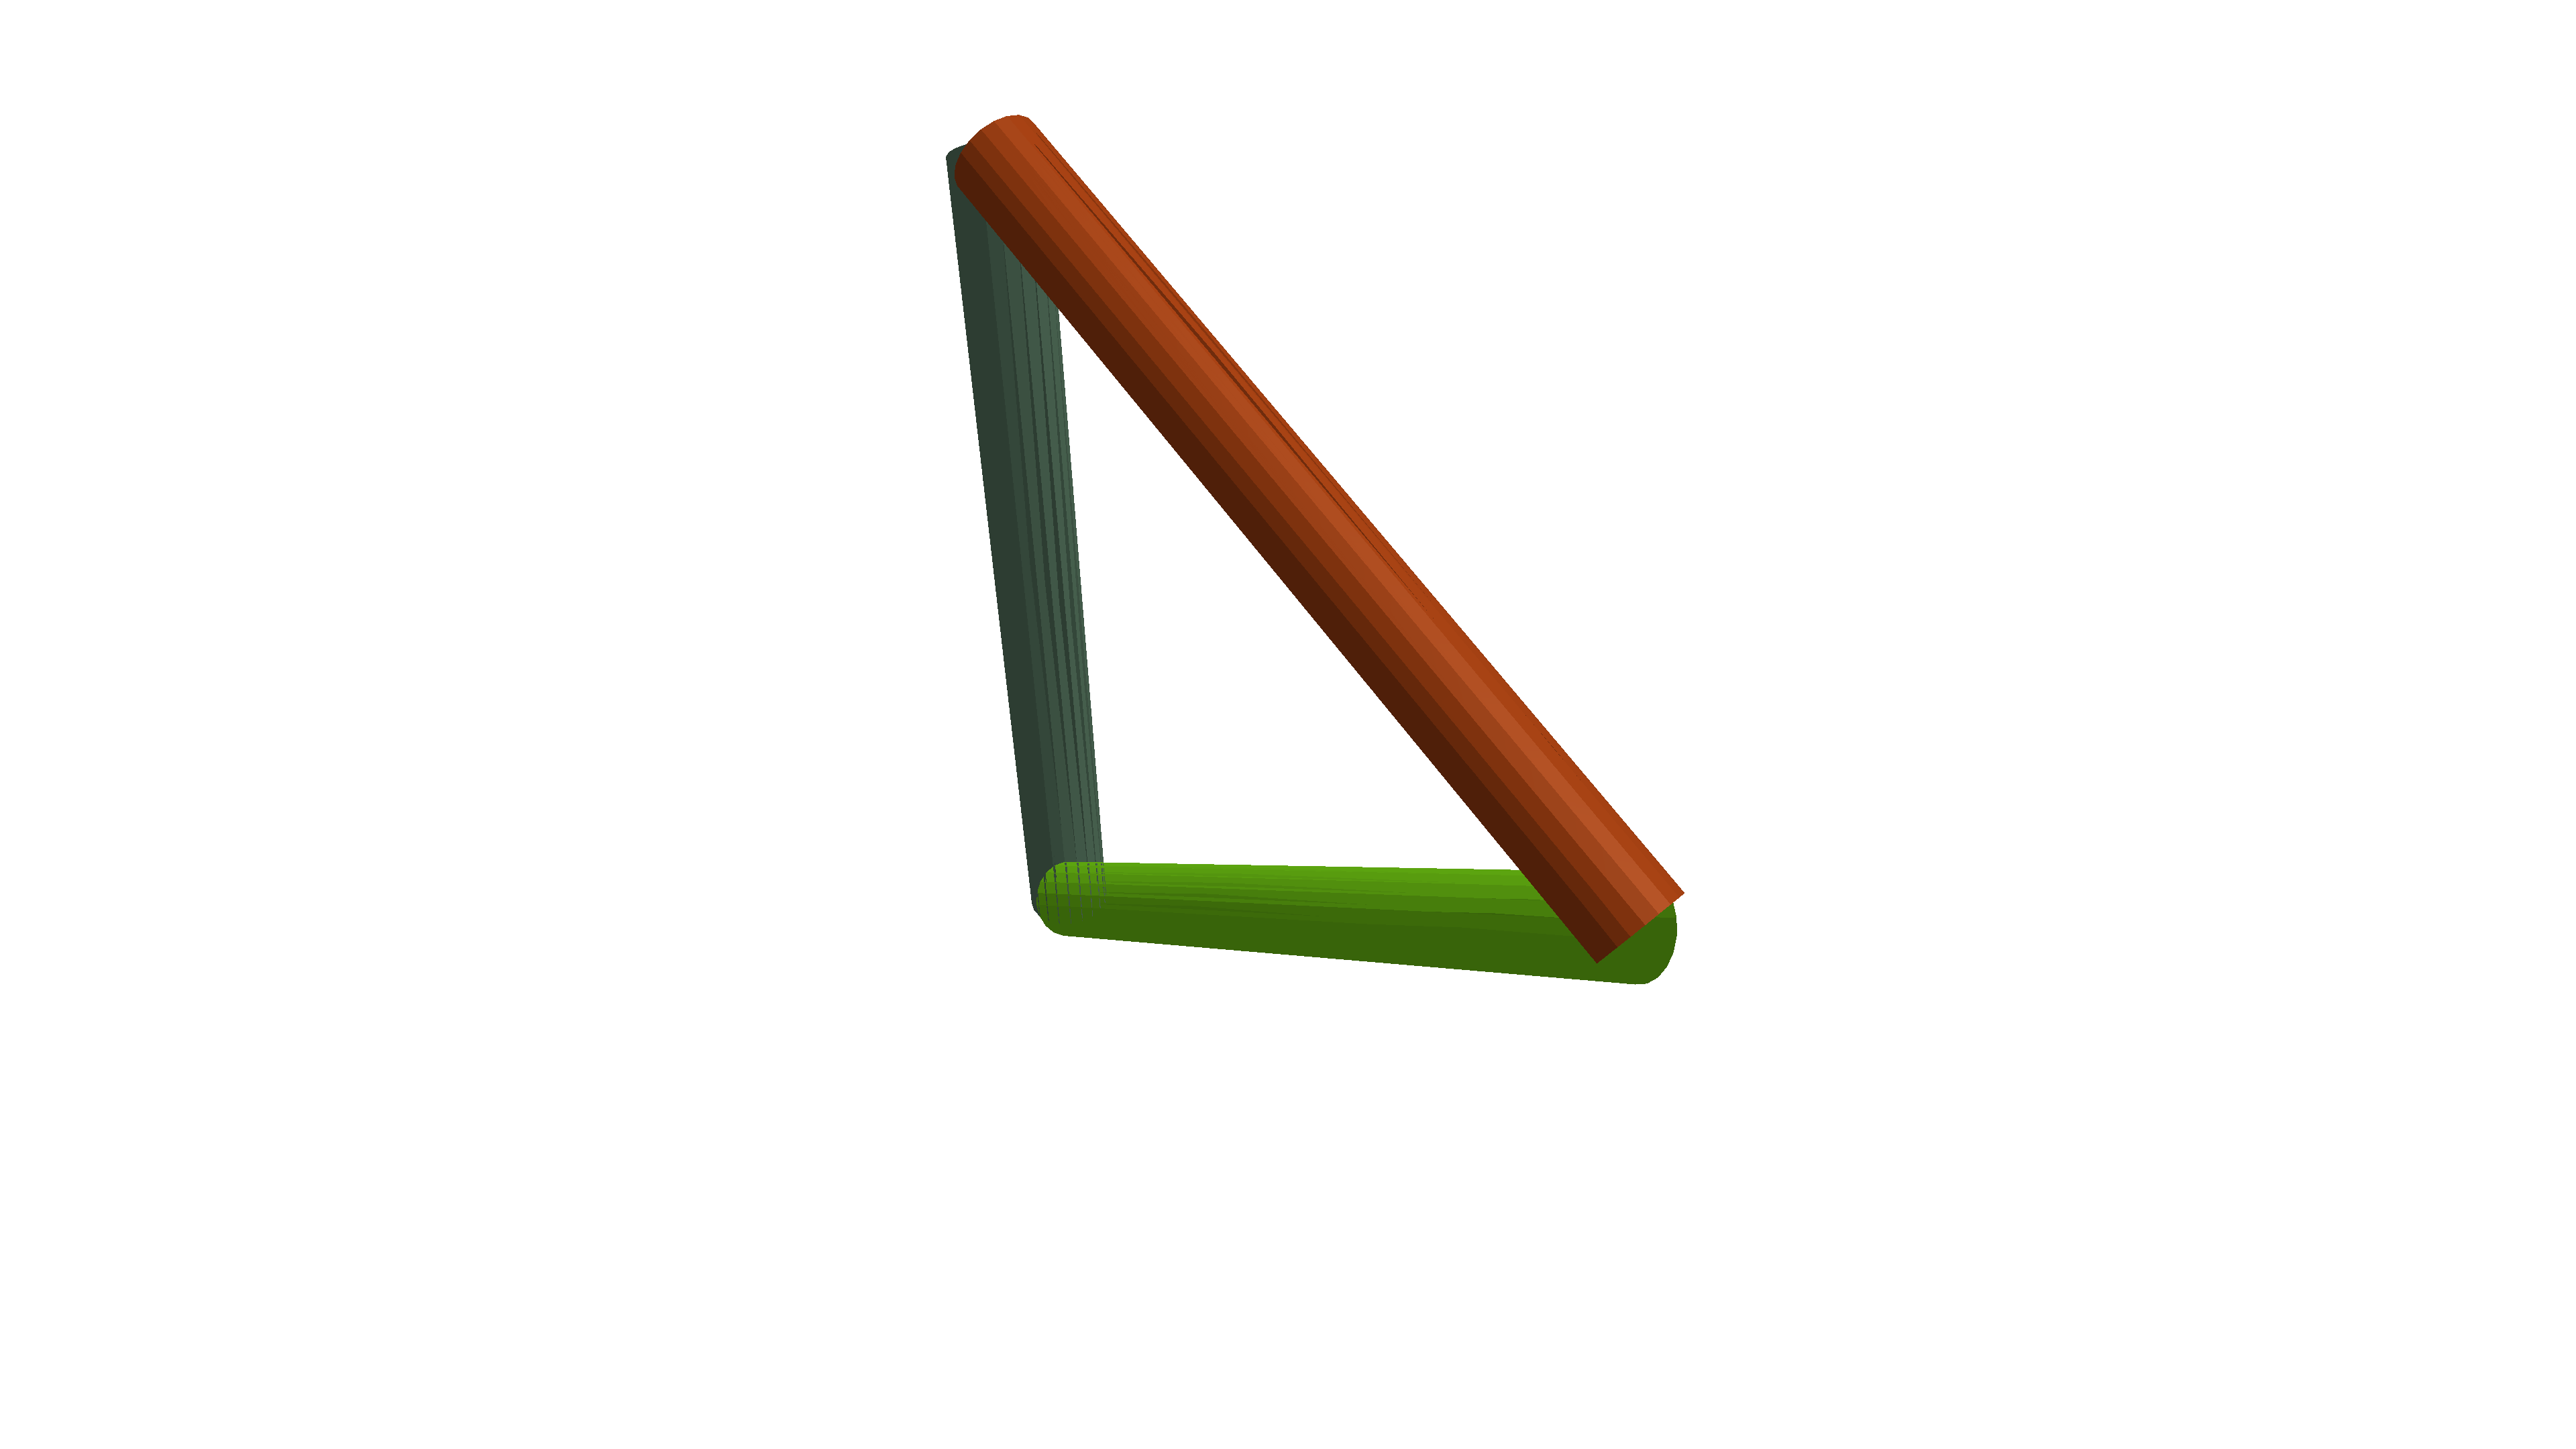

In [14]:
sc = Mesh(Koch)
render(sc, axes = false)

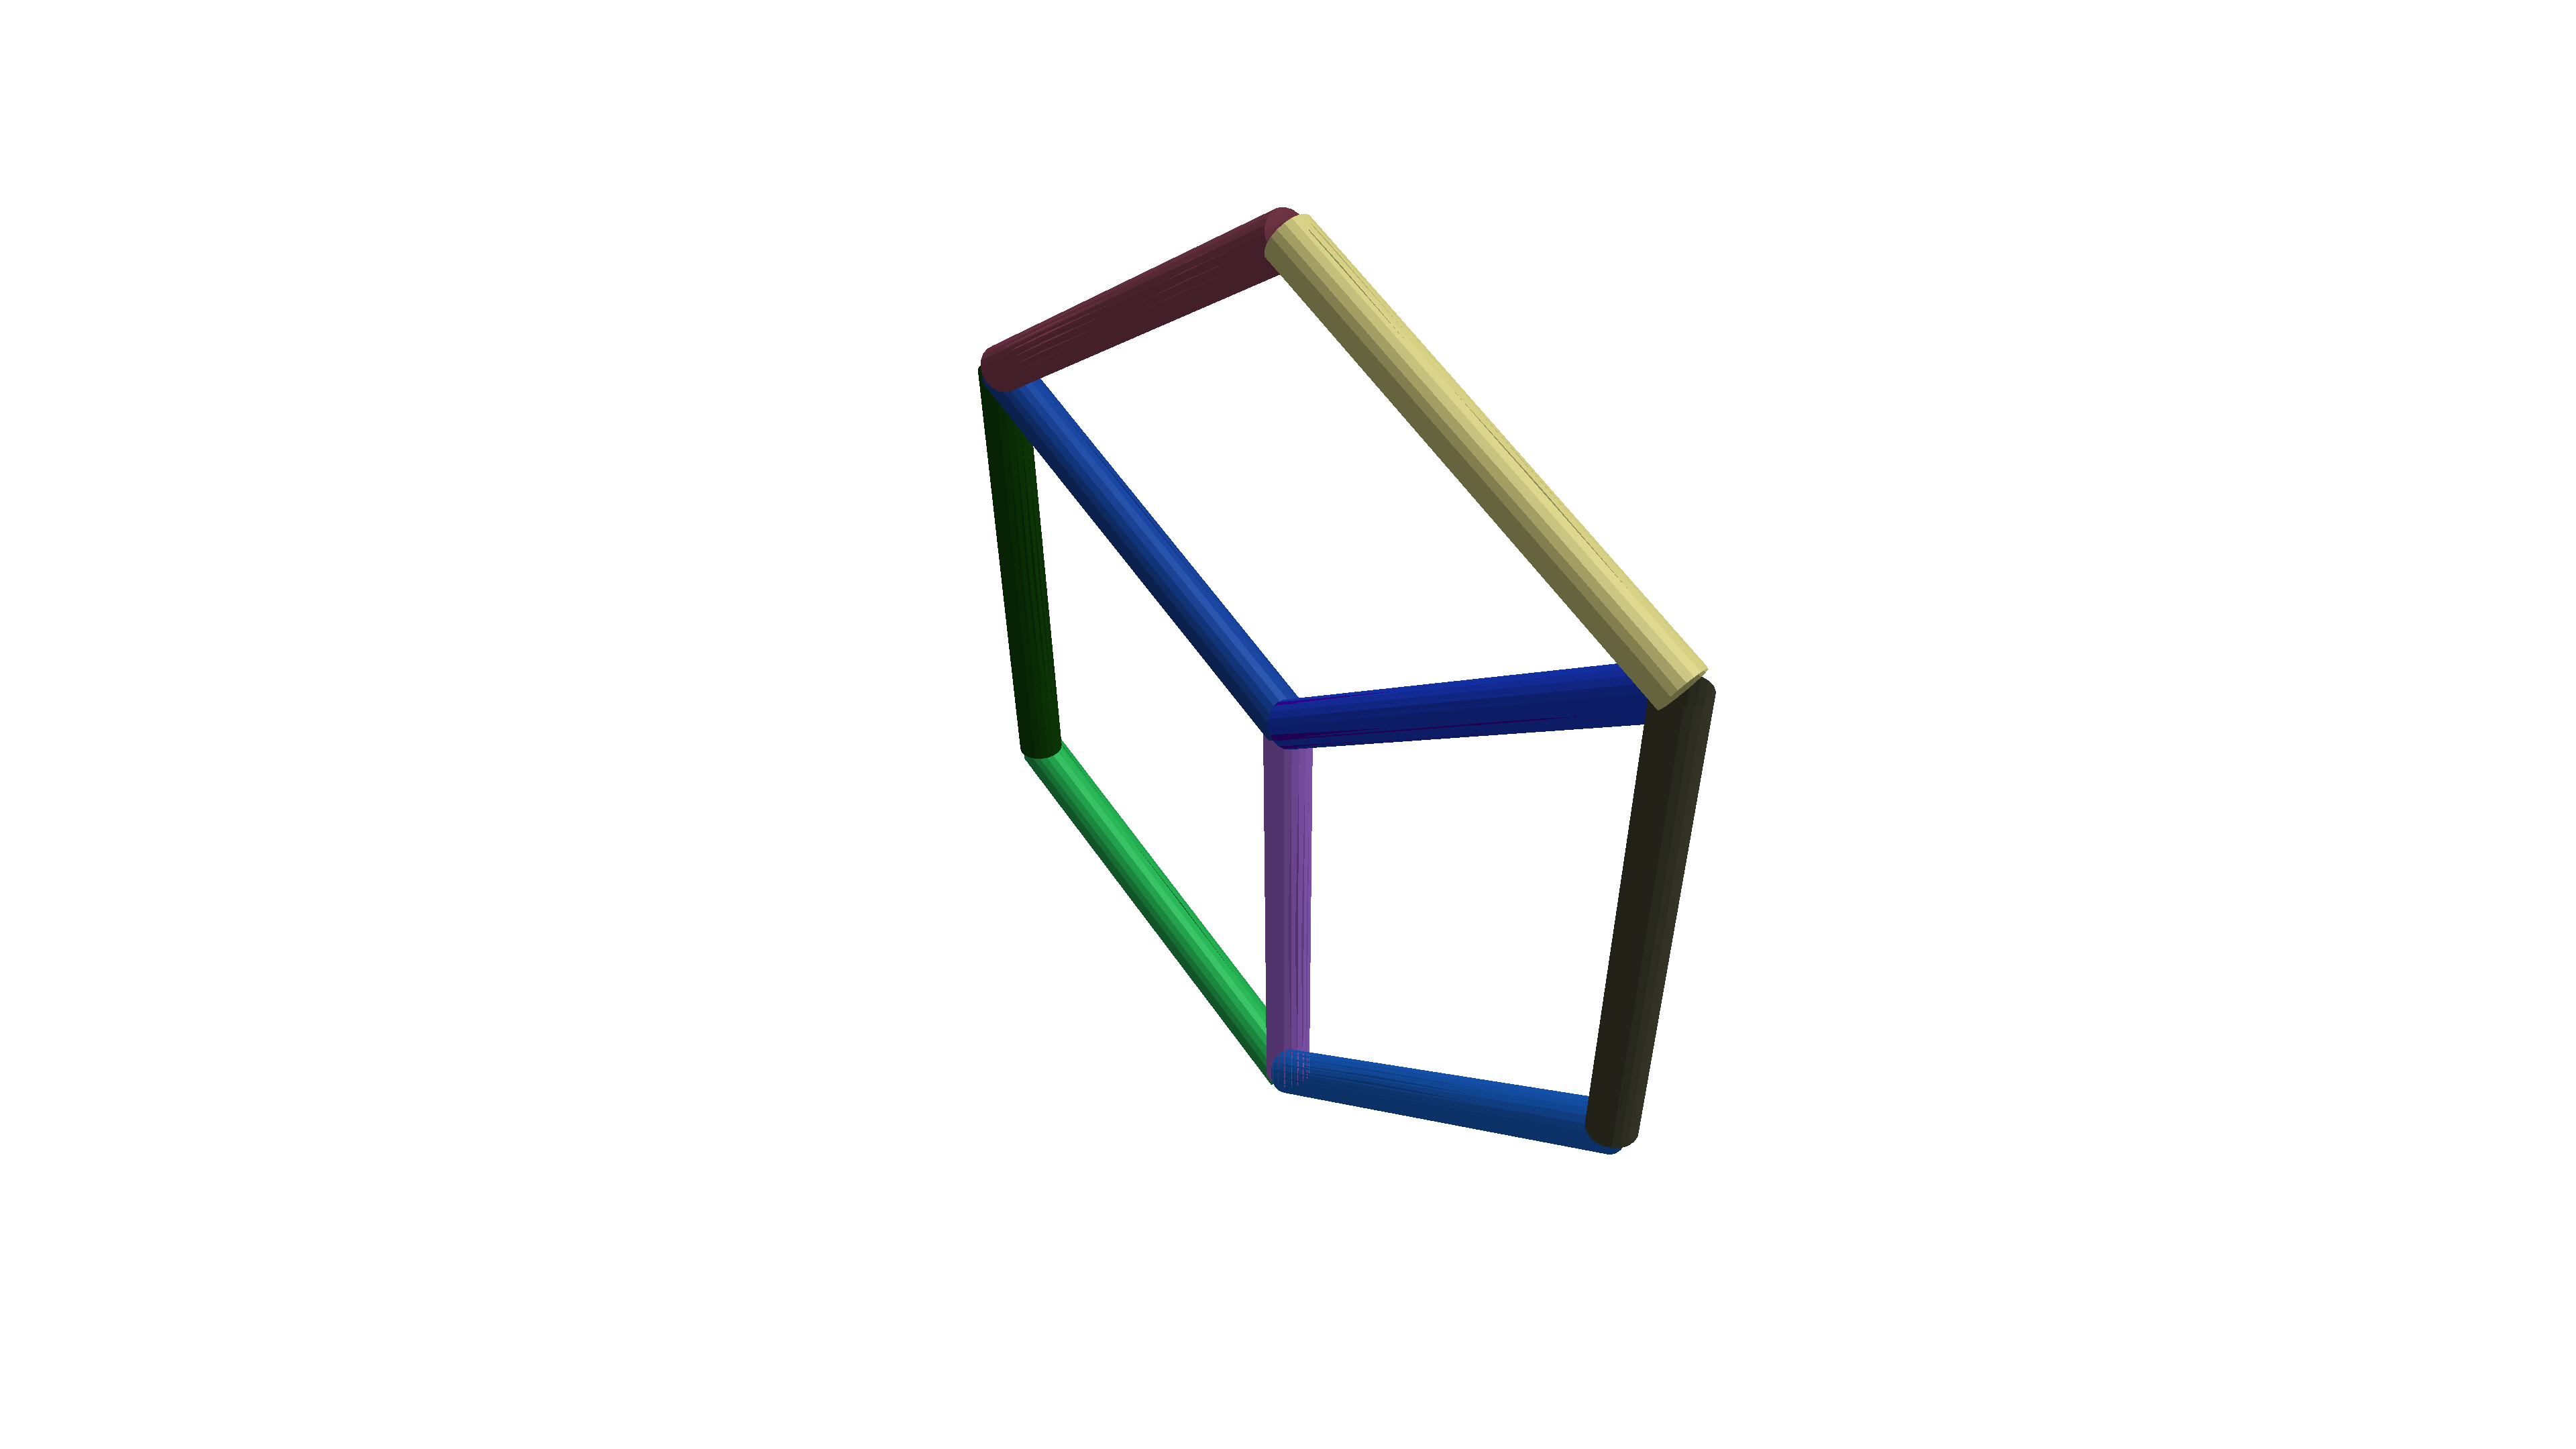

In [15]:
rewrite!(Koch)
render(Mesh(Koch), axes = false)

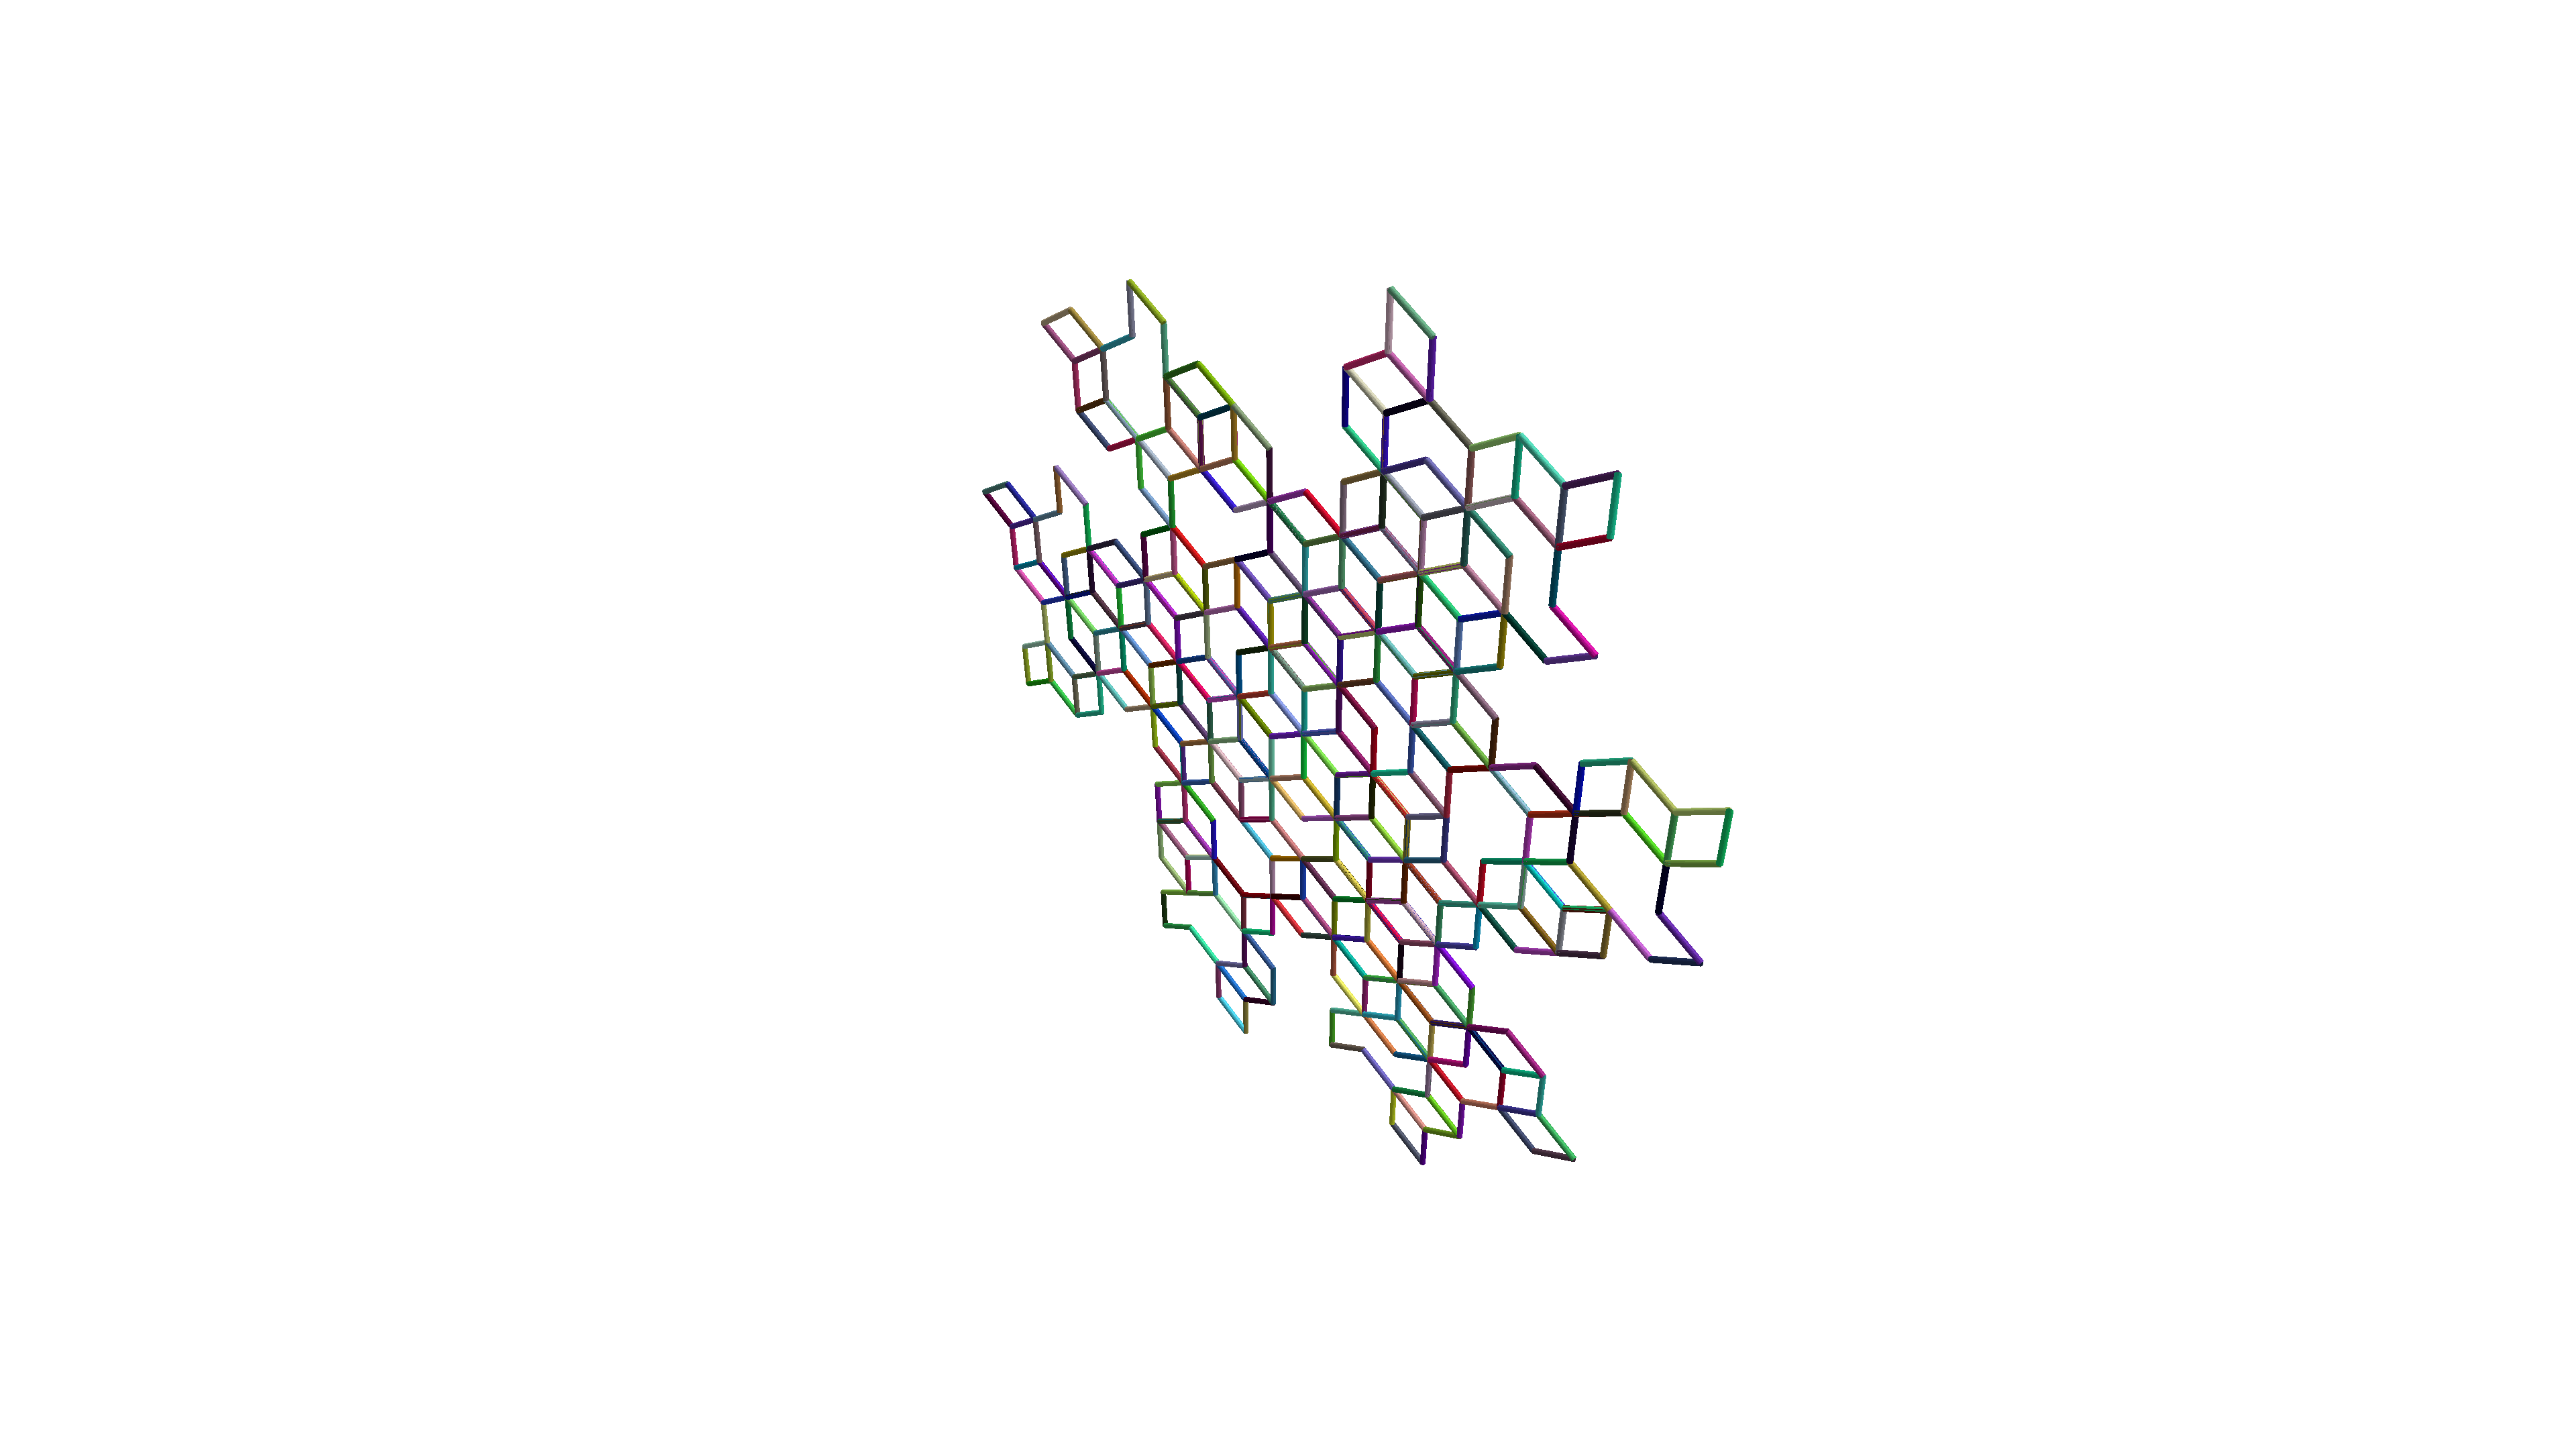

In [16]:
for i in 1:3
    rewrite!(Koch)
end
render(Mesh(Koch), axes = false)

In [17]:
function Kochsnowflake2(x)
   L = data(x).length
   sn.E(L/3) + RU(60.0) + sn.E(L/3) + RU(-120.0) + sn.E(L/3) + RU(60.0) + sn.E(L/3)
end
rule2 = Rule(sn.E, rhs = Kochsnowflake2)
Koch2 = Graph(axiom = axiom, rules = Tuple(rule2))

Dynamic graph with 5 nodes of types Main.sn.E,RU{Float64} and 1 rewriting rules.


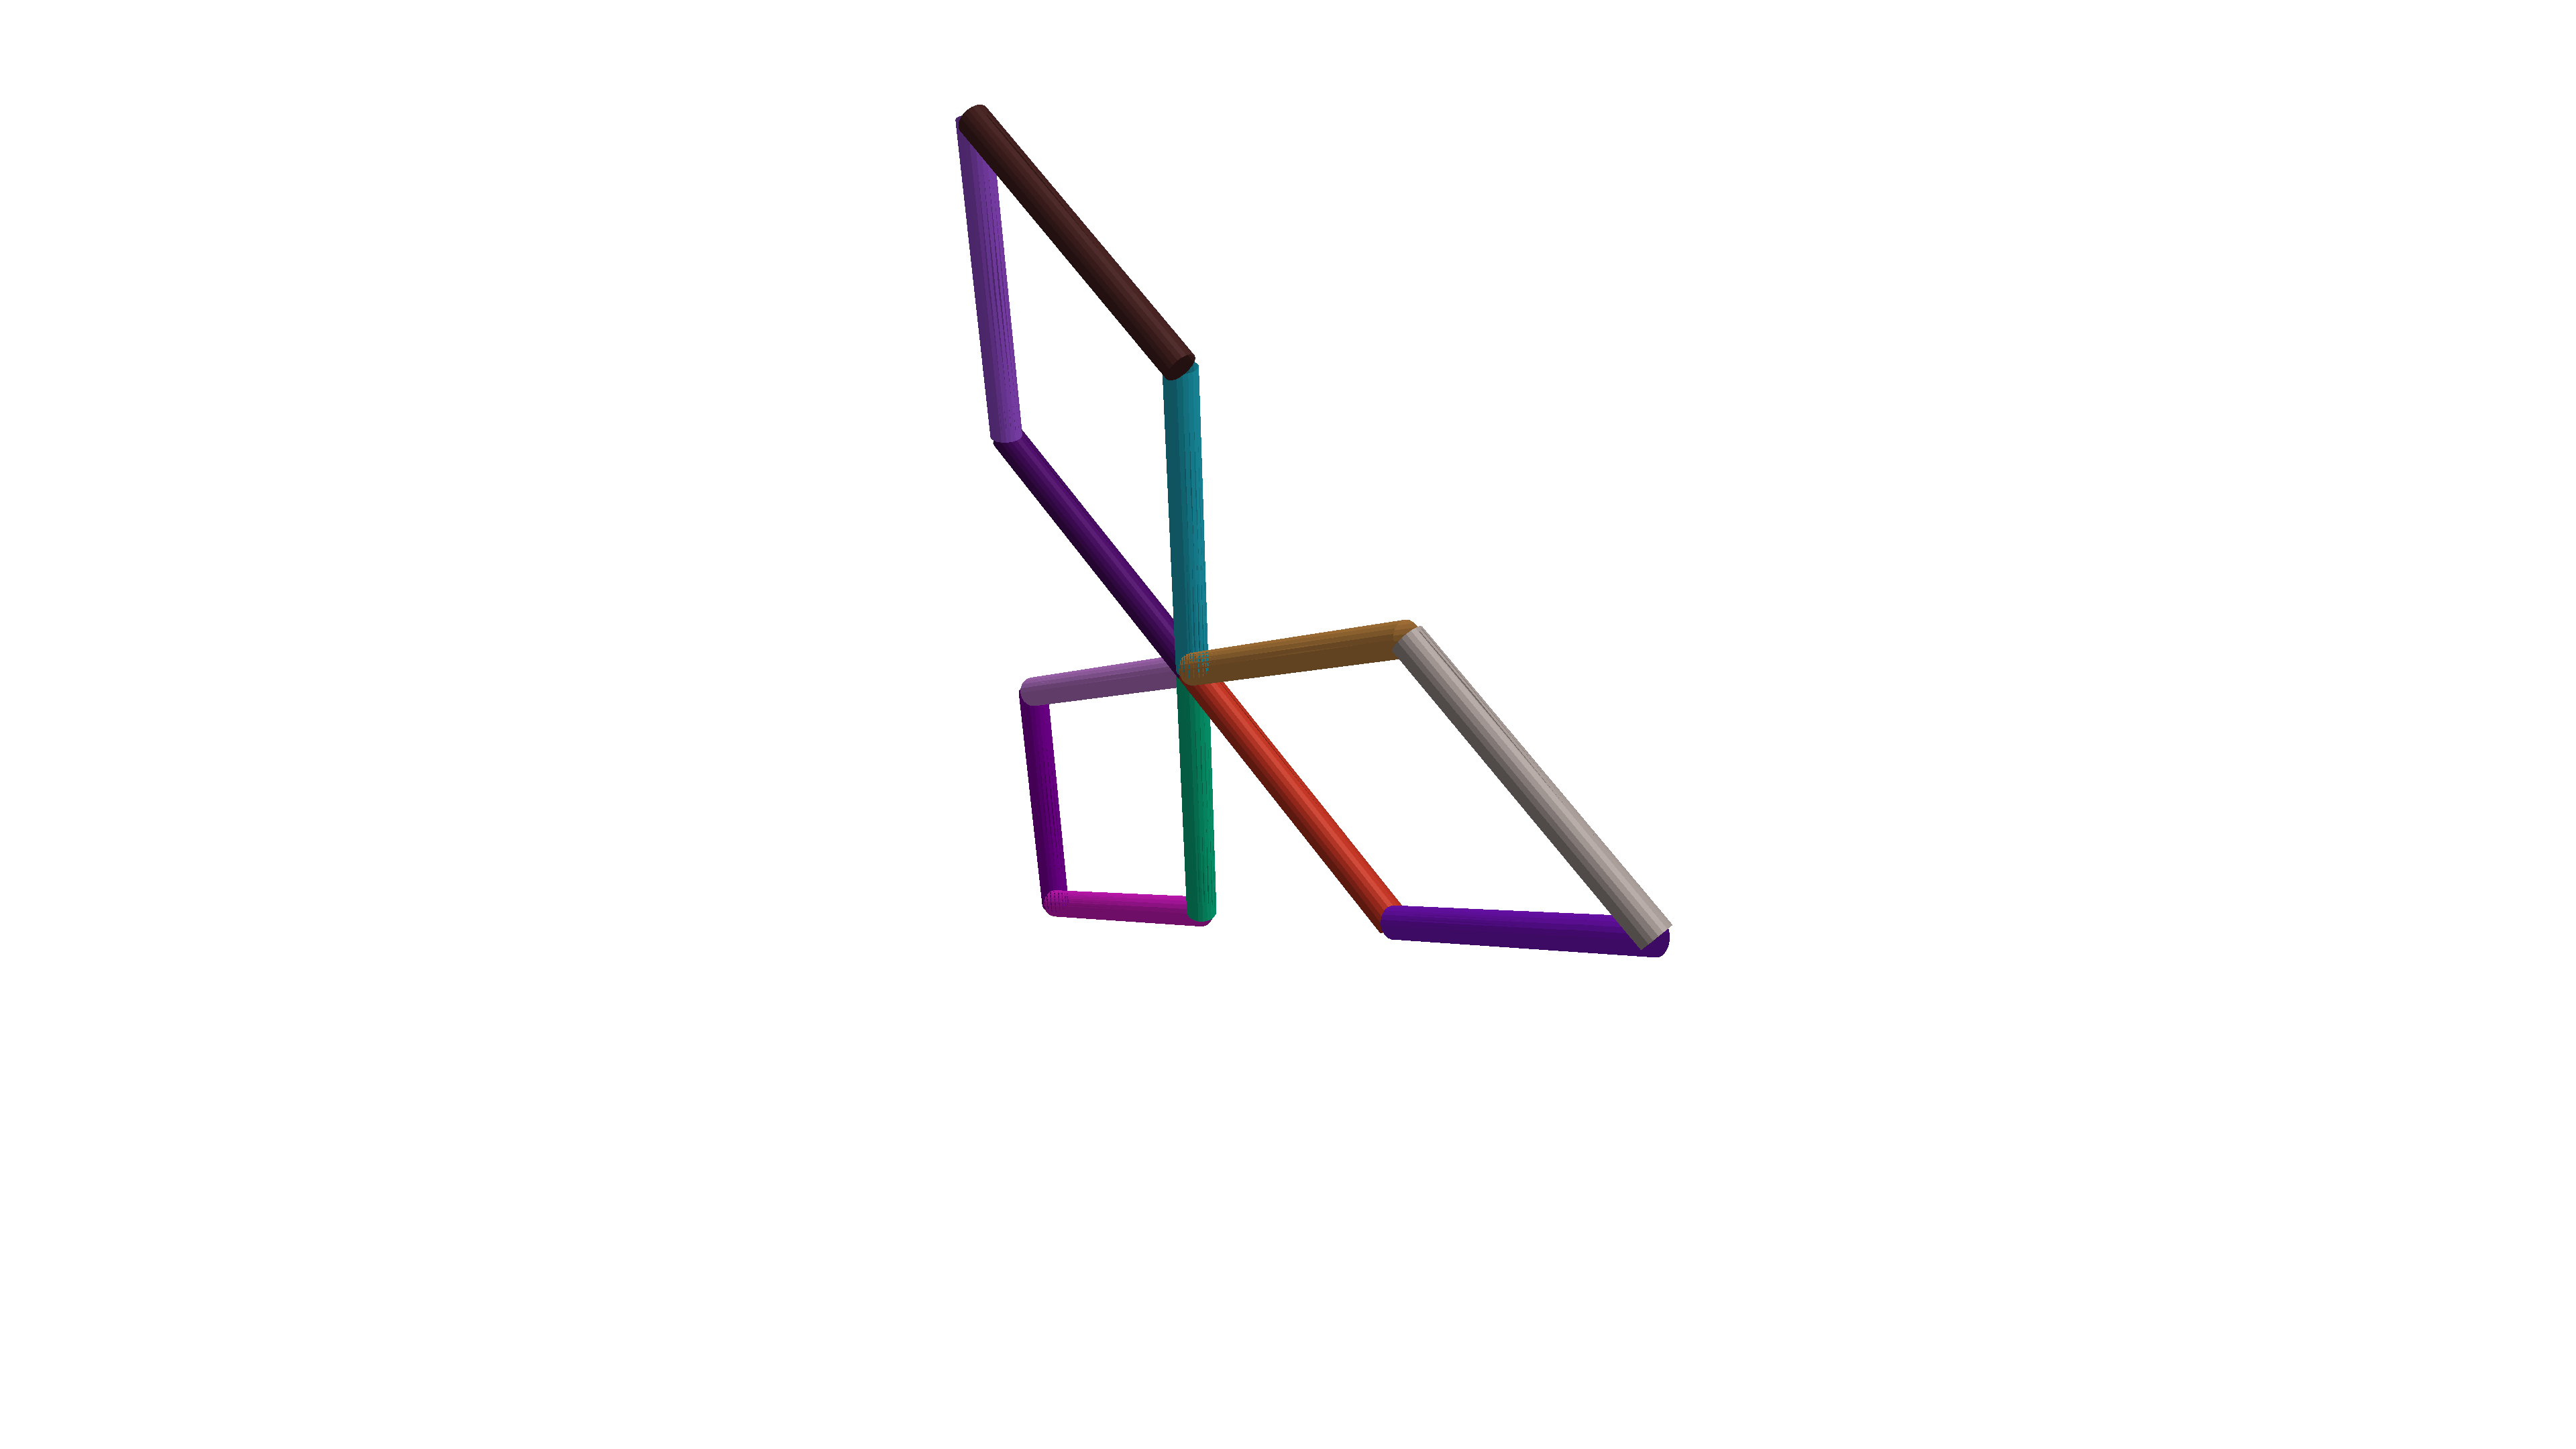

In [18]:
rewrite!(Koch2)
render(Mesh(Koch2), axes = false)

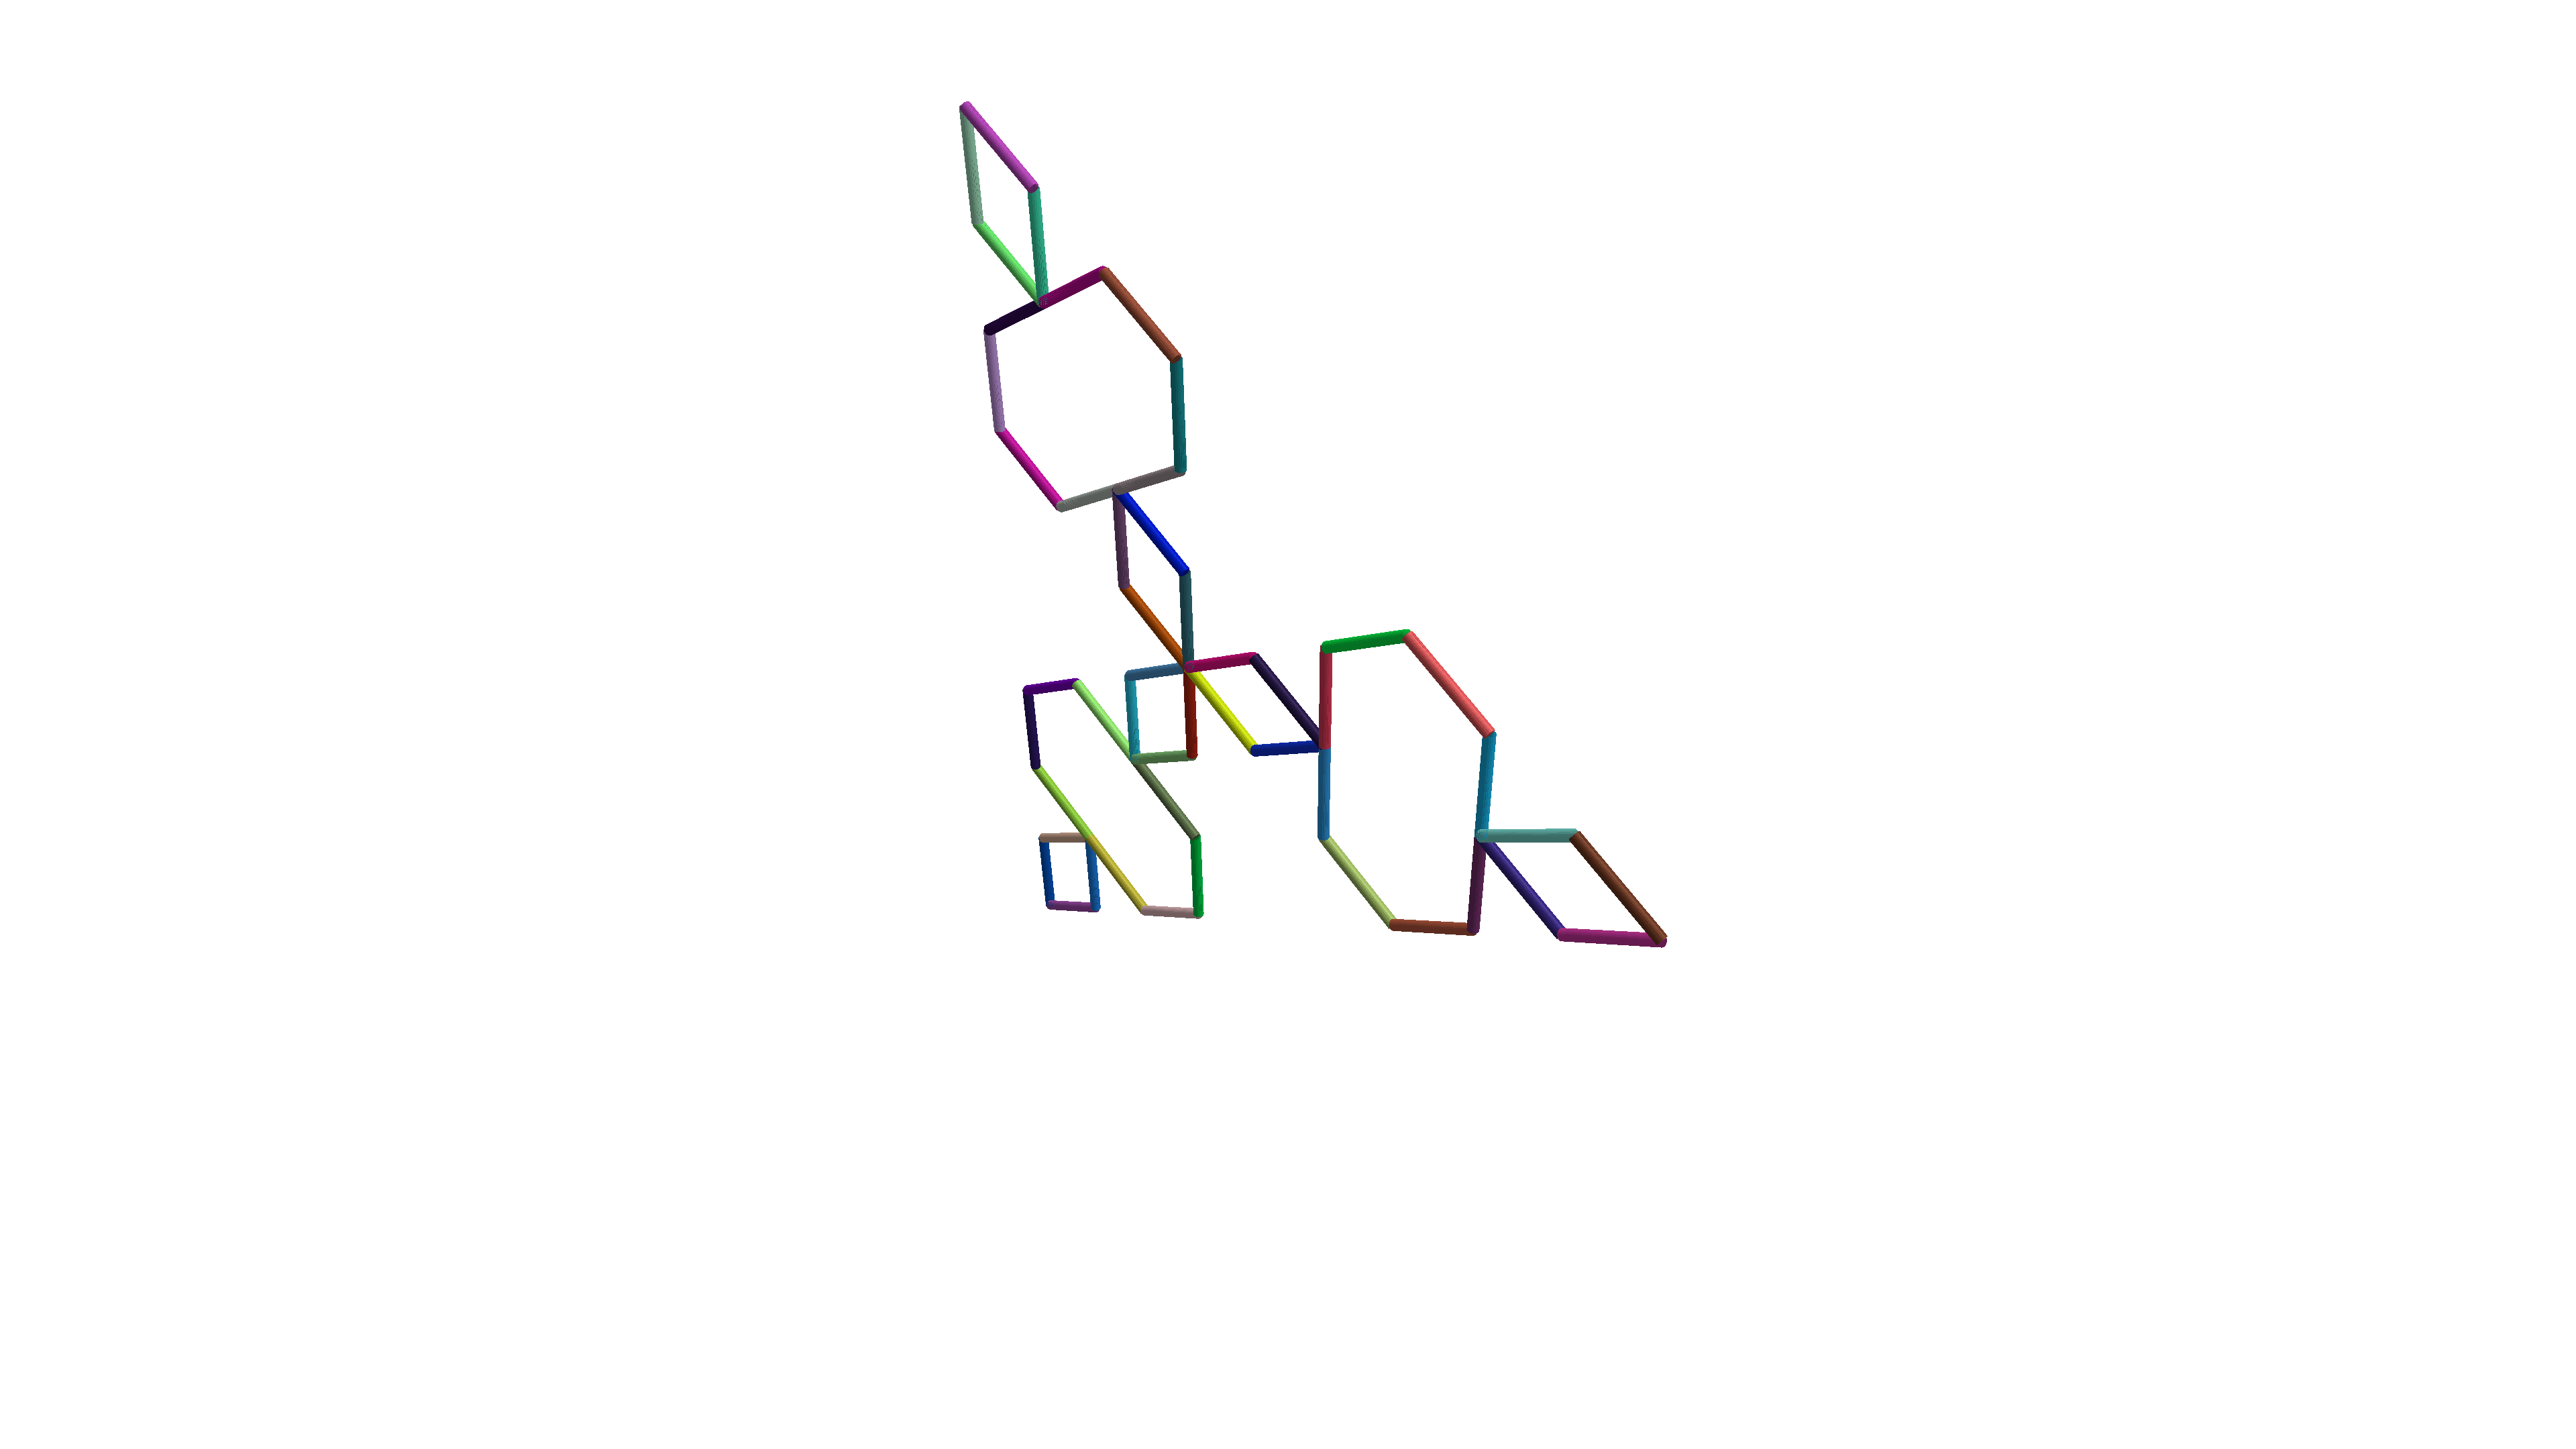

In [19]:
rewrite!(Koch2)
render(Mesh(Koch2), axes = false)

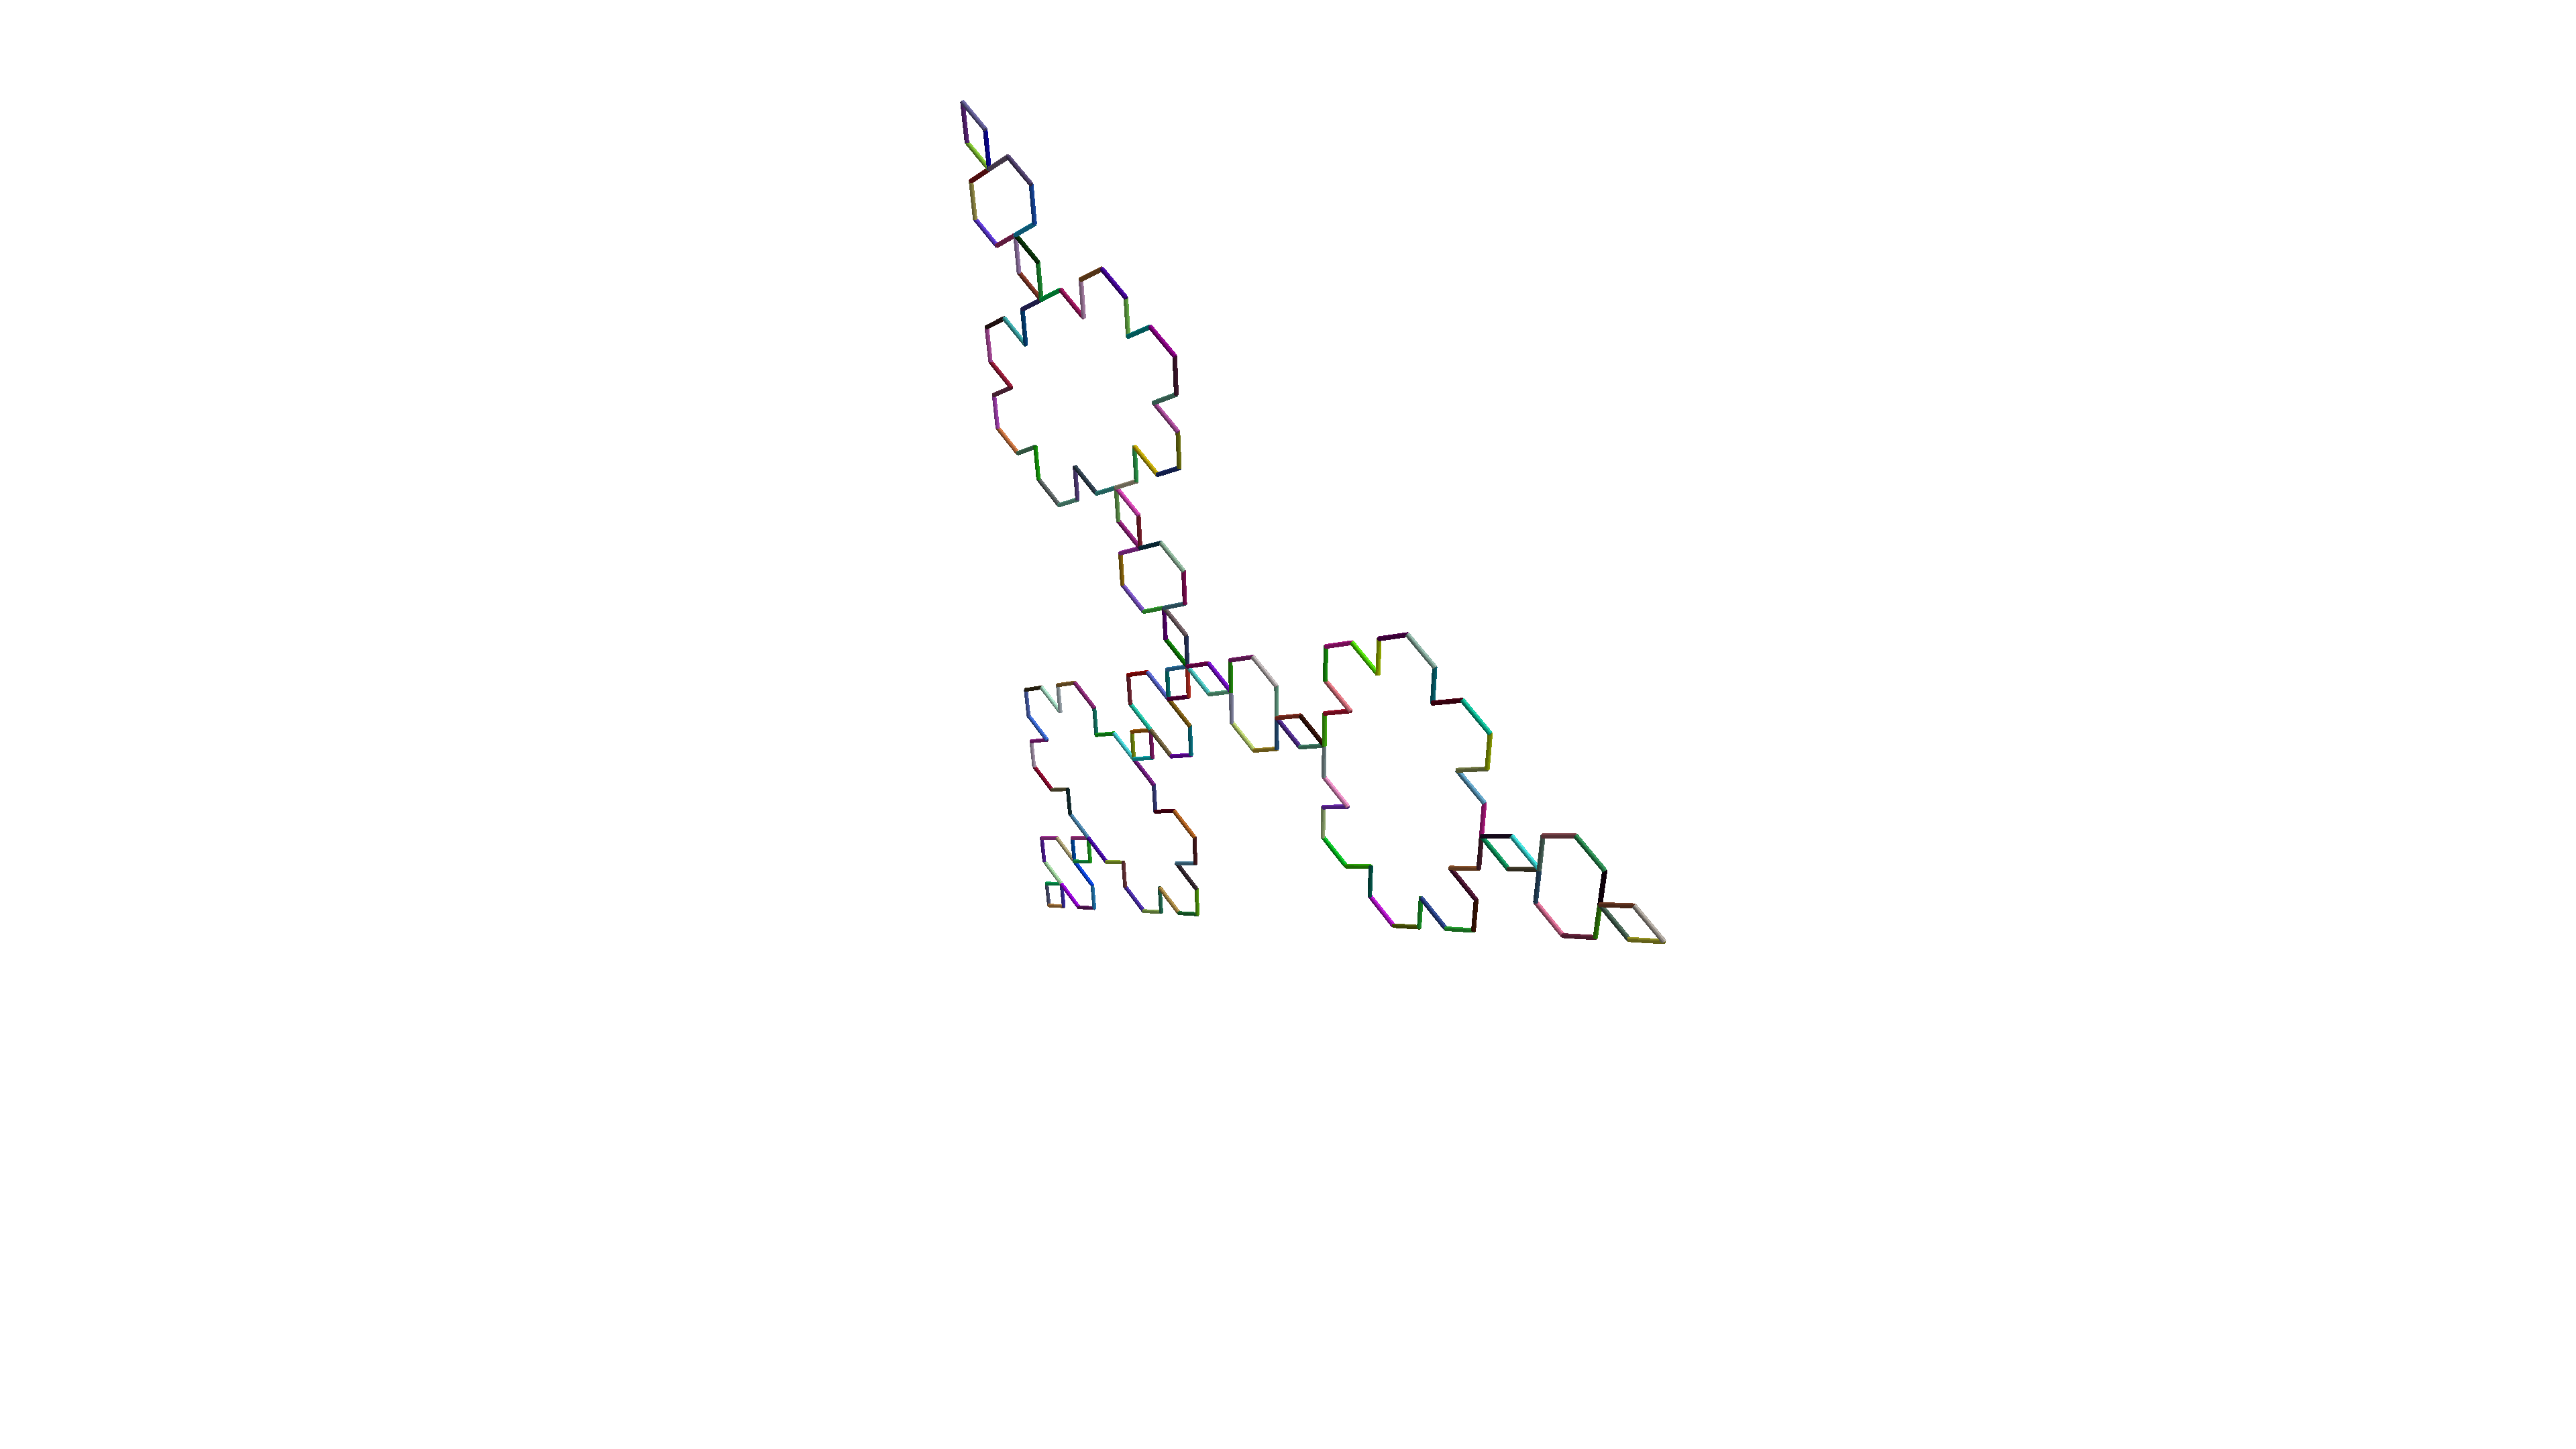

In [20]:
rewrite!(Koch2)
render(Mesh(Koch2), axes = false)

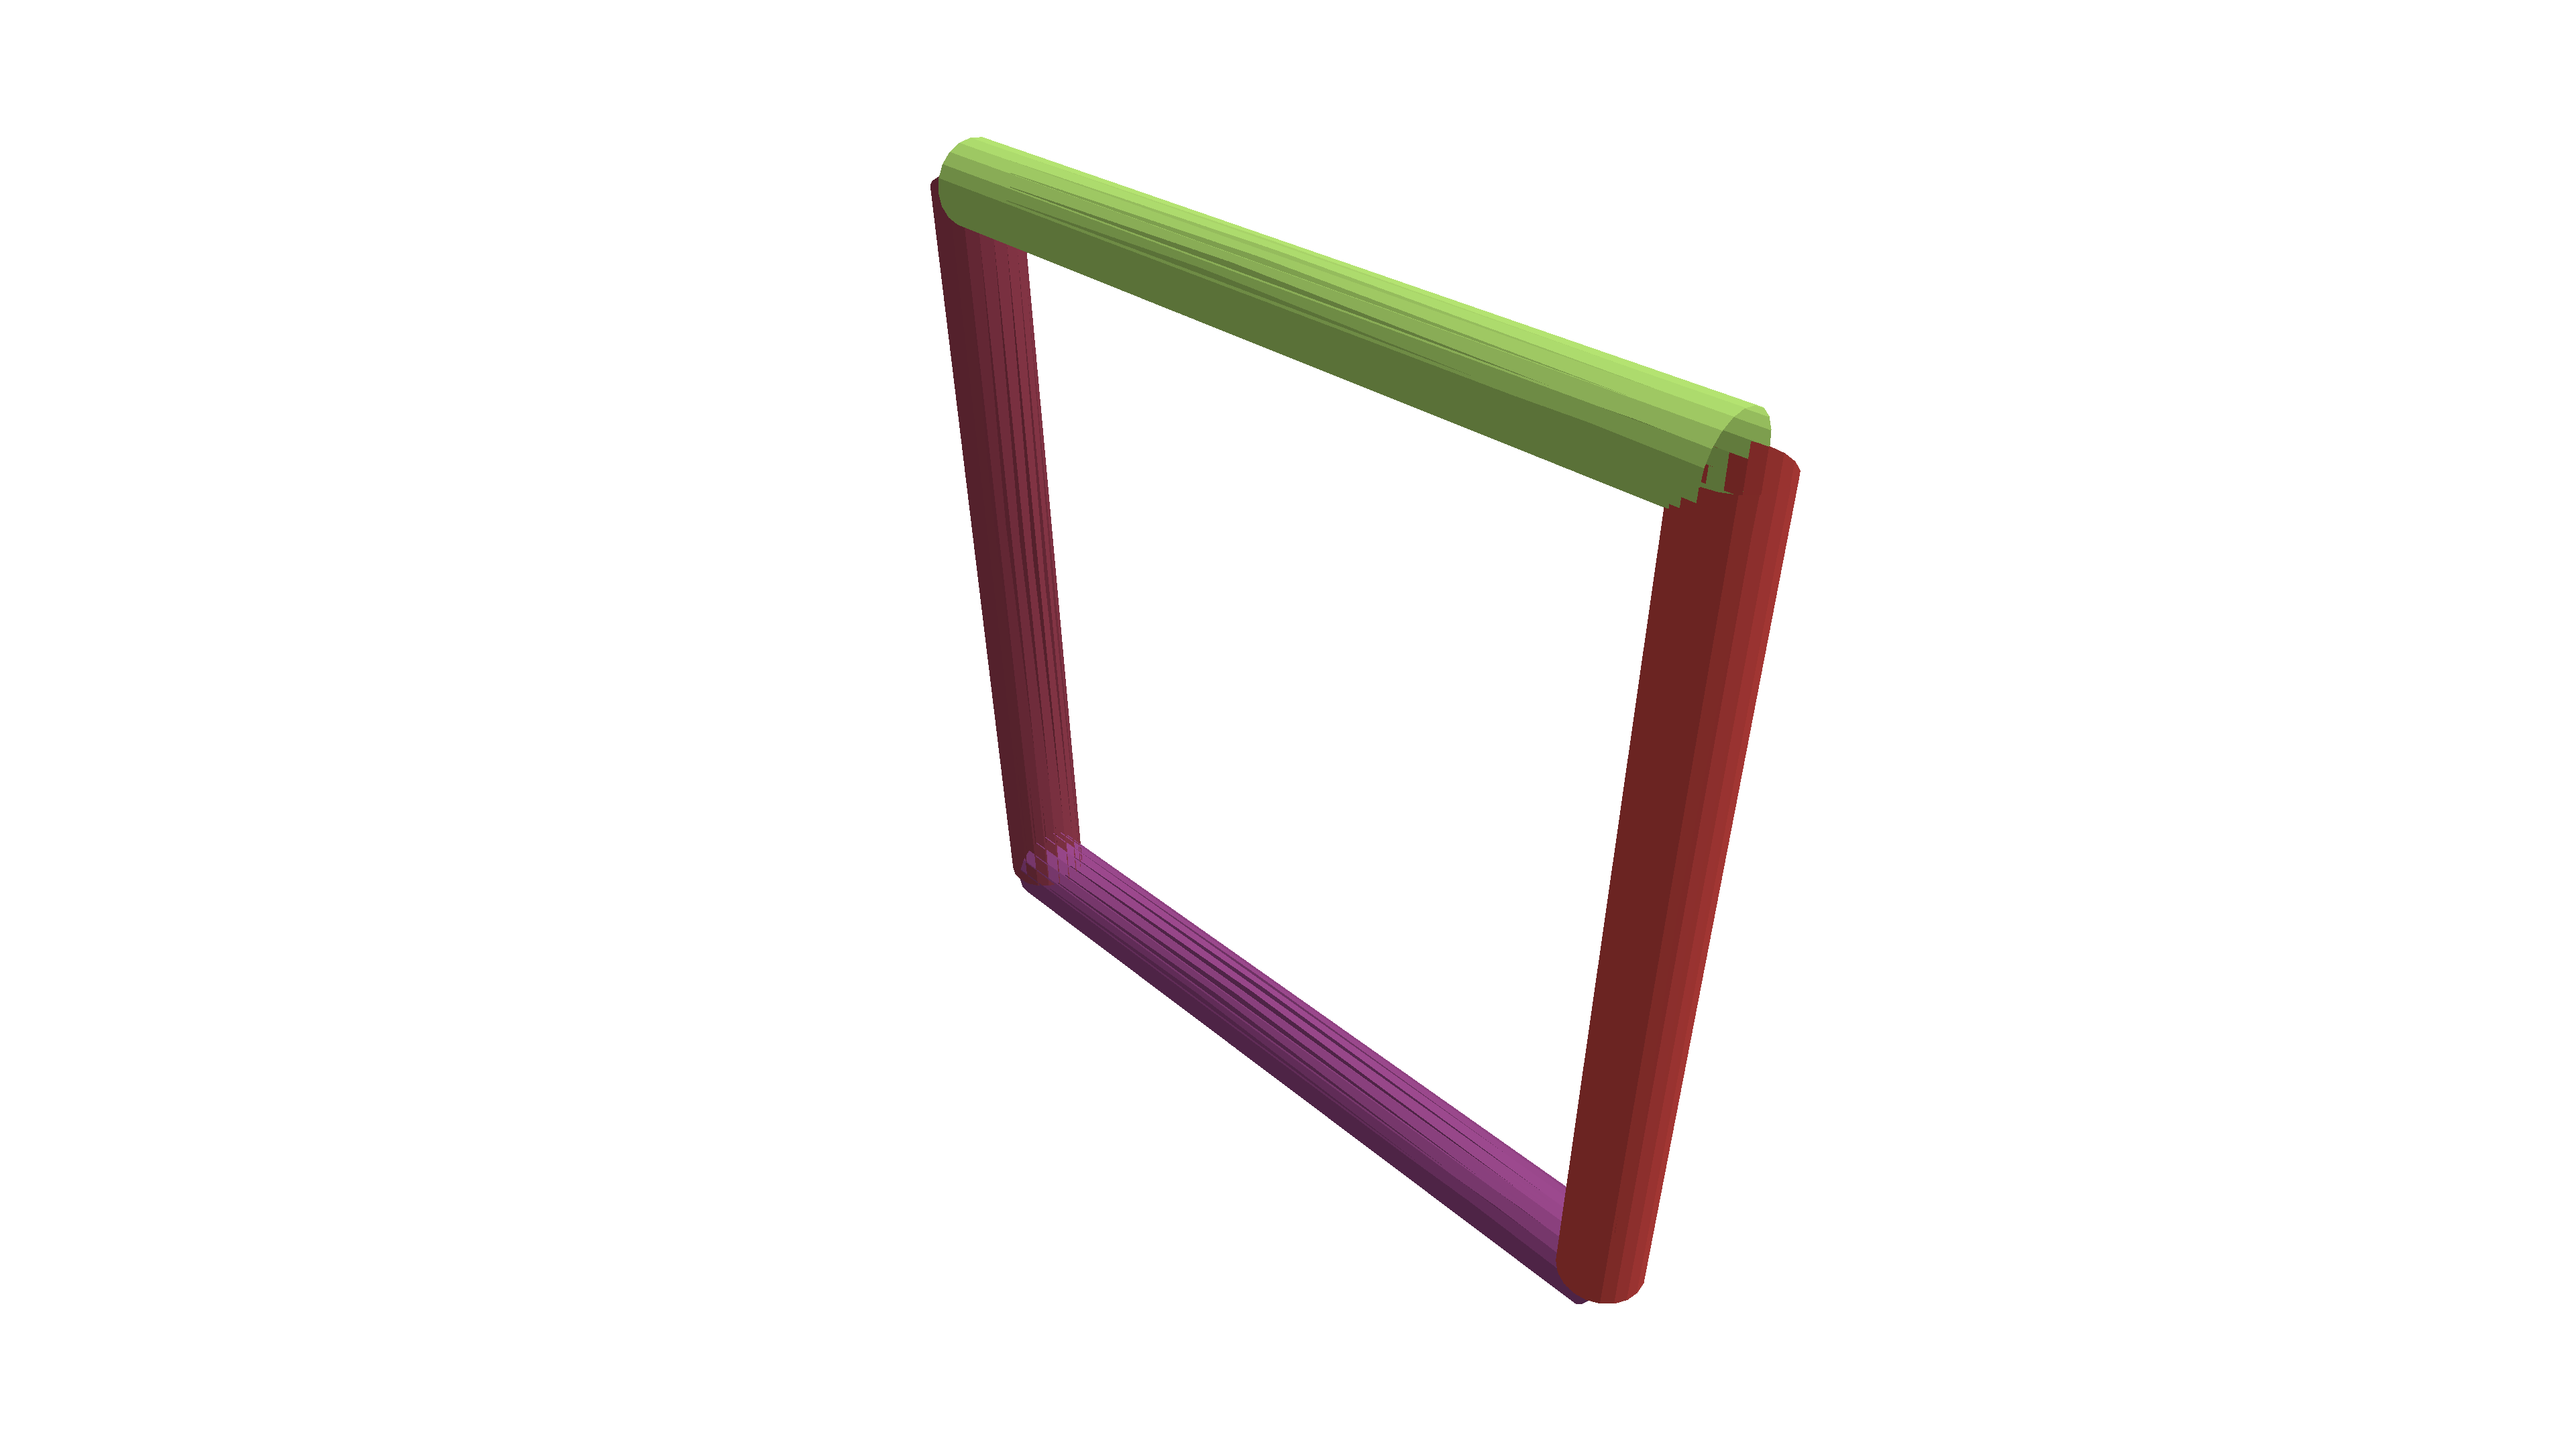

In [21]:
axiomCesaro = sn.E(L) + RU(90.0) + sn.E(L) + RU(90.0) + sn.E(L) + RU(90.0) + sn.E(L)
Cesaro = Graph(axiom = axiomCesaro, rules = (rule2,))
render(Mesh(Cesaro), axes = false)

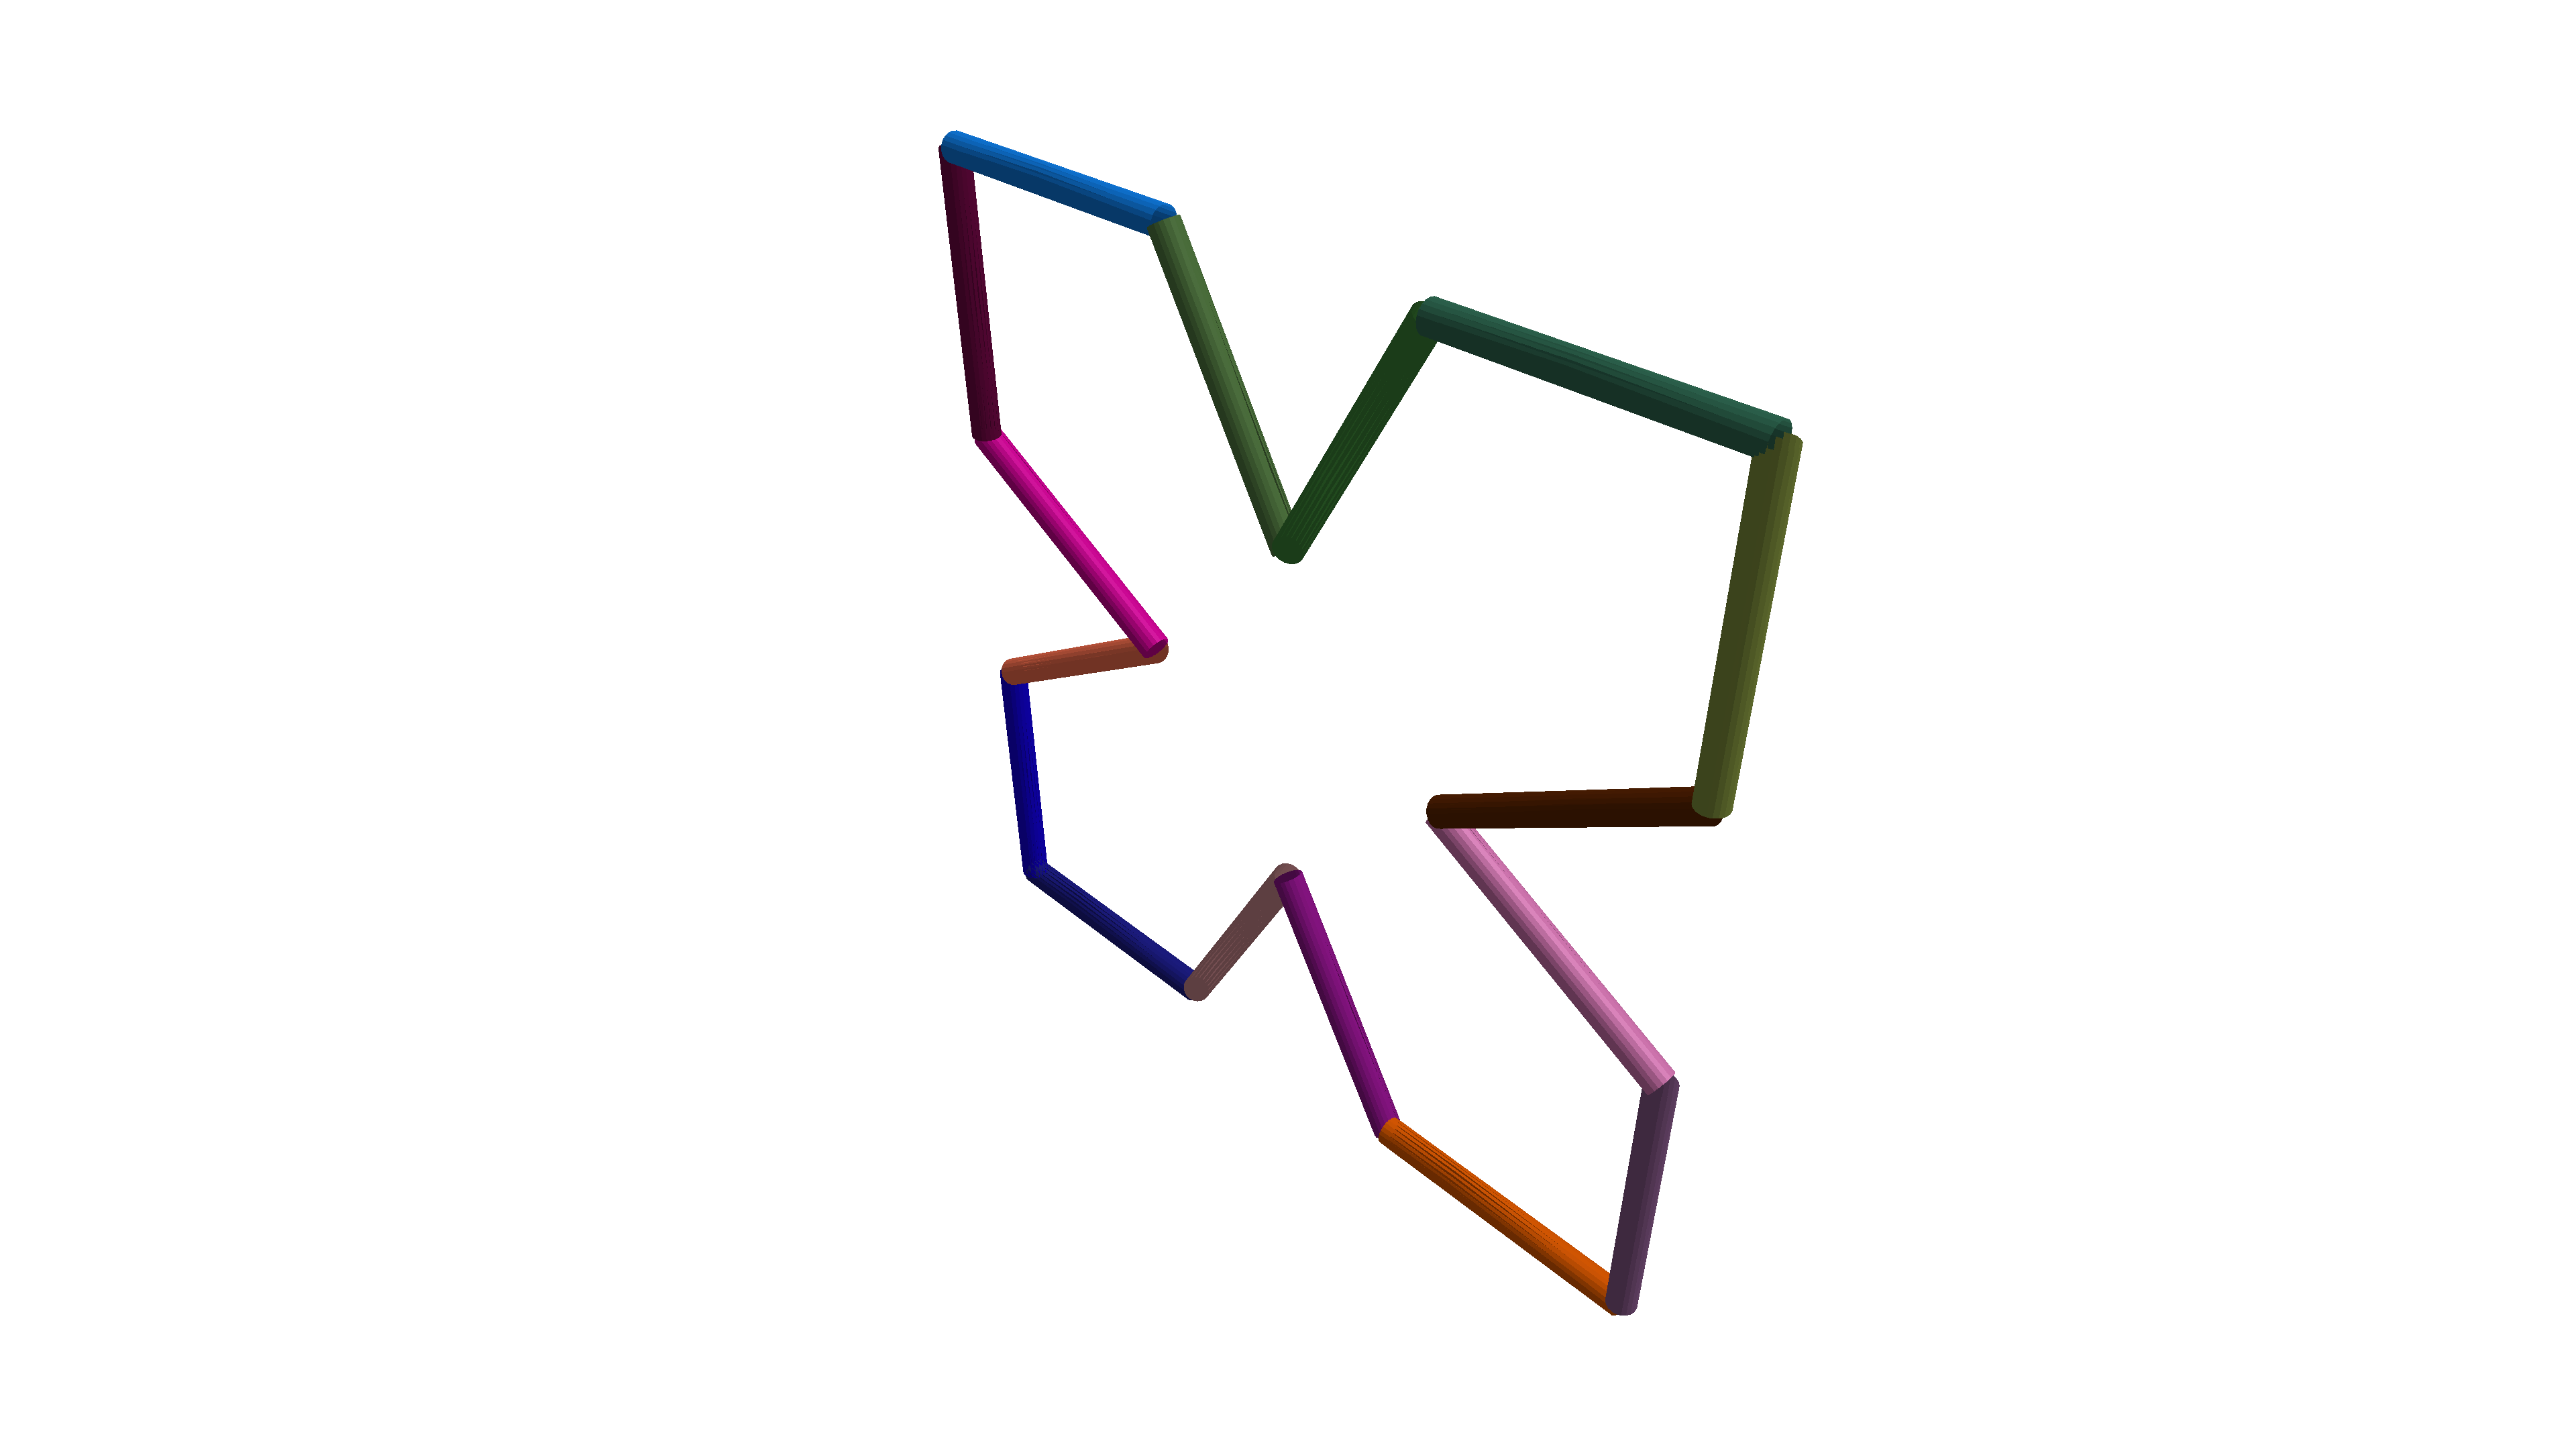

In [22]:
# first iteration
rewrite!(Cesaro)
render(Mesh(Cesaro), axes = false)

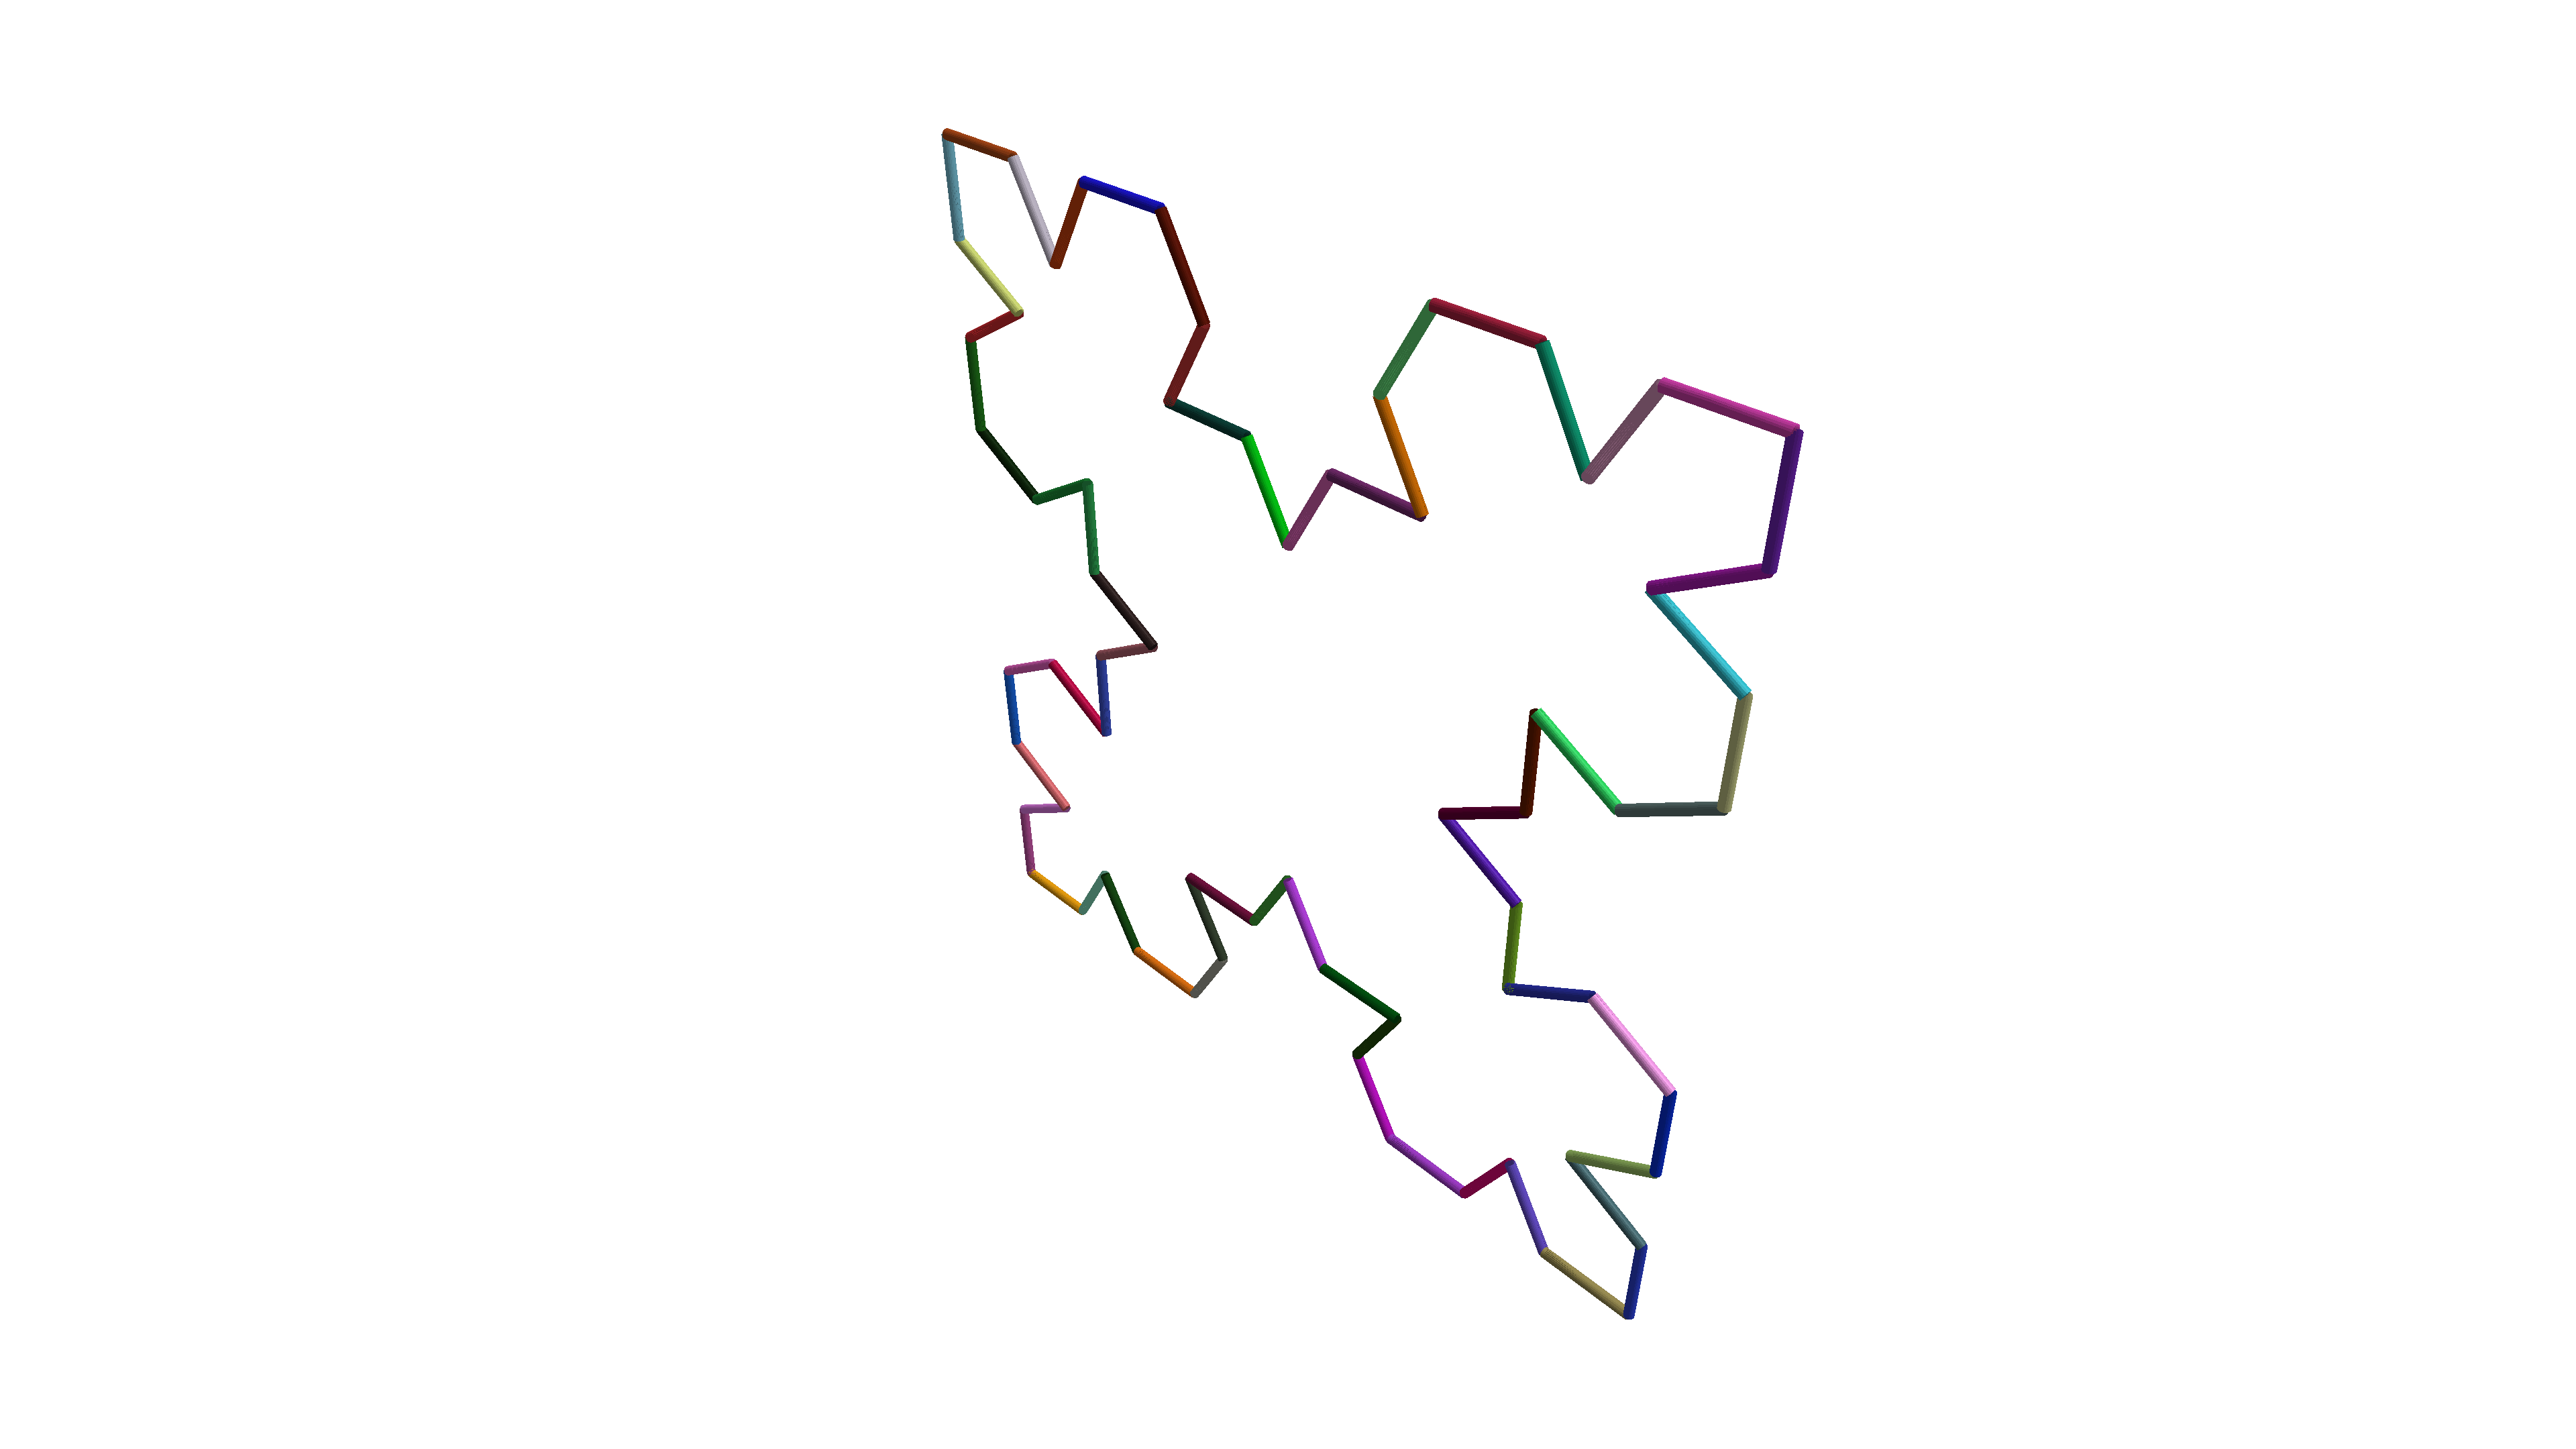

In [23]:
# second interation
rewrite!(Cesaro)
render(Mesh(Cesaro), axes = false)

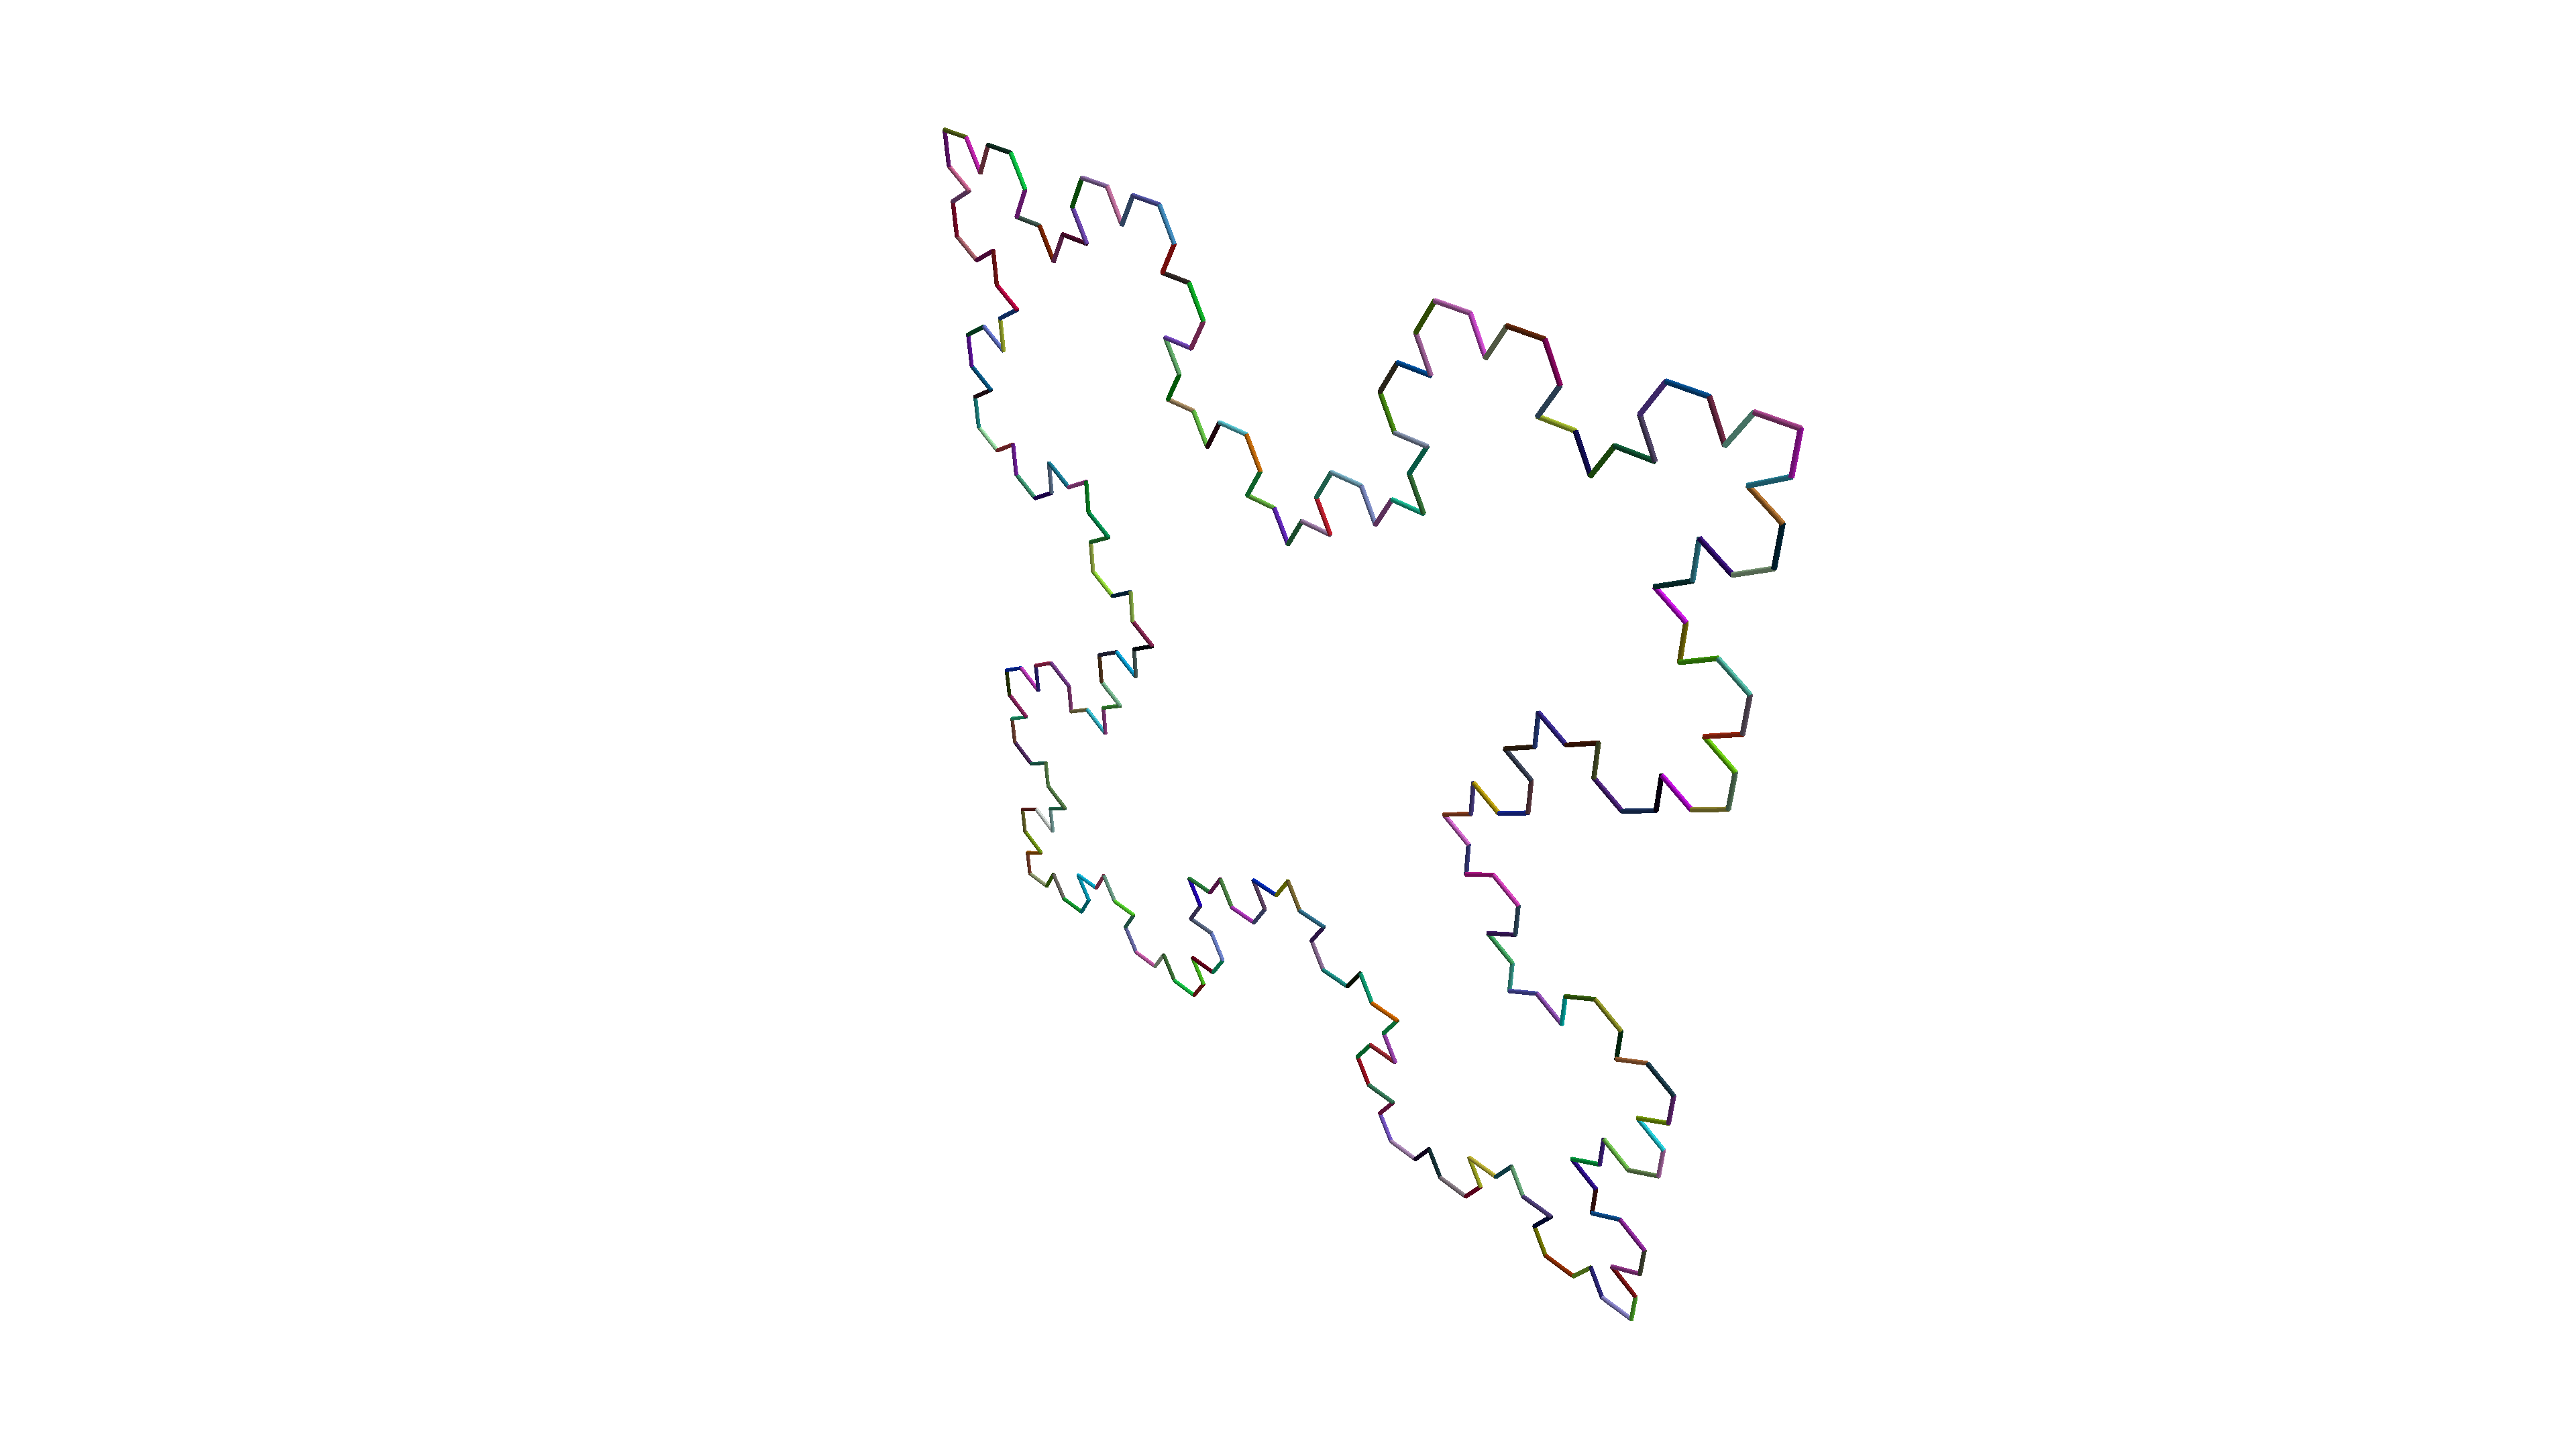

In [24]:
#third interation
rewrite!(Cesaro)
render(Mesh(Cesaro), axes = false)